In [1]:
%load_ext autoreload
%autoreload 2

# SPY Trend Following Study

## Theory

### Hypothesis
- We can collect trend premium by going long SPY when the trend is up and short SPY when the trend is down.
- The trend premium should allow us to get better risk-adjusted returns than SPY alone.
- The lookback period associated with the returns is an adjustable parameter.
- We hypothesize optimal lookback period depends on the market regime. In particular, we suspect that shorter lookback periods are better during high volatility periods.

### Strategy
- Forecast the forward volatility
- Split the data into two groups based on the volatility forecast via a threshold.
- Optimize the lookback period for each group.




## Libraries

In [2]:
import pandas as pd
import numpy as np
from utils.backtester import BackTester
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
from utils.data_fetcher import YahooDataFetcher
import datetime
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, TimeSeriesSplit
import lightgbm as lgb
import optuna
from indicators.returns import calculate_binary_forward_returns, calculate_binary_returns, calculate_binary_MA_returns, calculate_forward_returns, calculate_returns, calculate_MA_returns
from indicators.breakout import calculate_breakout
from indicators.volatility import calculate_atr, calculate_forward_vol
from indicators.volume import calculate_rel_volume
from indicators.trend import calculate_r2

## Data Loading

In [3]:
# Current date
current_date = datetime.datetime.now().date()
current_date = current_date.strftime("%Y%m%d")
print(current_date)
# current_date = "20250321"

# # Fetch daily price data from Yahoo Finance
# fetcher = YahooDataFetcher()
# ticker_list = ['SPY', '^VIX']
# fetcher.load_price_data(tickers=ticker_list)

ticker = "SPY"
df_raw = pd.read_pickle(f'data/raw/price/{ticker}_{current_date}.pkl') 

20250331


## Data Preparation

In [5]:
df_data = df_raw.copy()
df_data['returns'] = df_data['close'].pct_change()
df_vix = pd.read_pickle(f'./data/raw/price/^VIX_{current_date}.pkl')
df_data['vol_forward'] = calculate_forward_vol(df_data, 21)
df_data['vix'] = df_vix['close']
df_data.dropna(inplace=True)
# df_price = df_raw.copy()

## Simple Trend Following

### Comparison

Compare buy-hold vs lookback = 21 vs lookback = 252

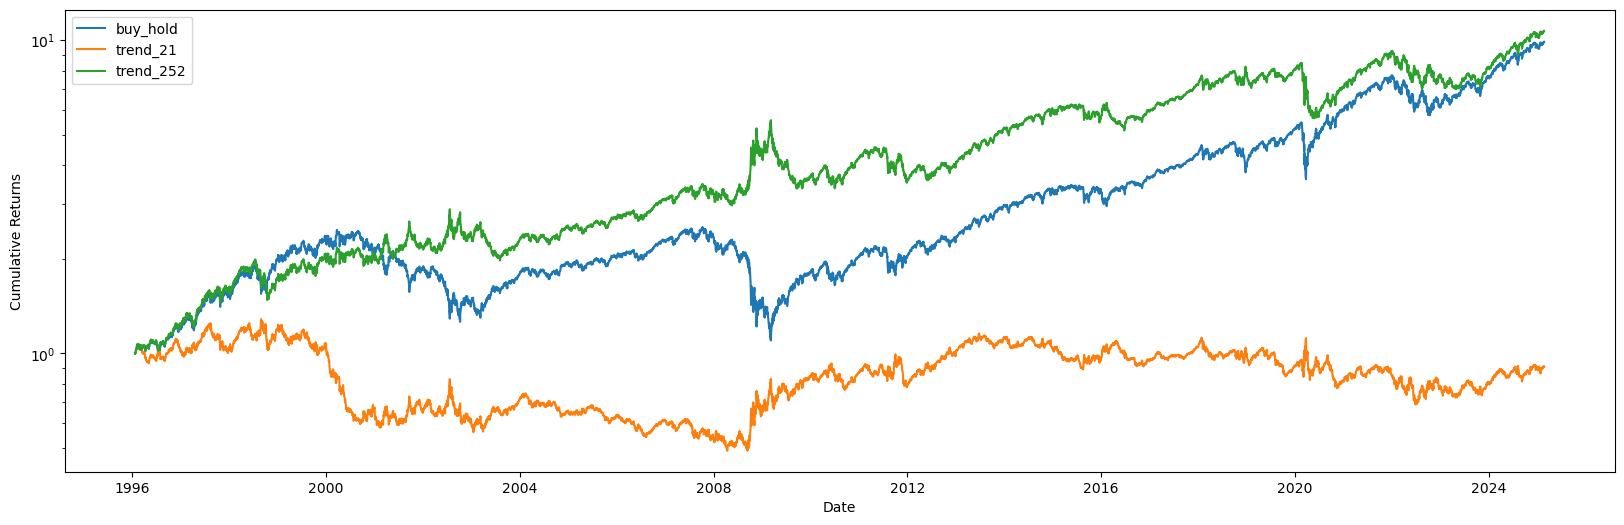

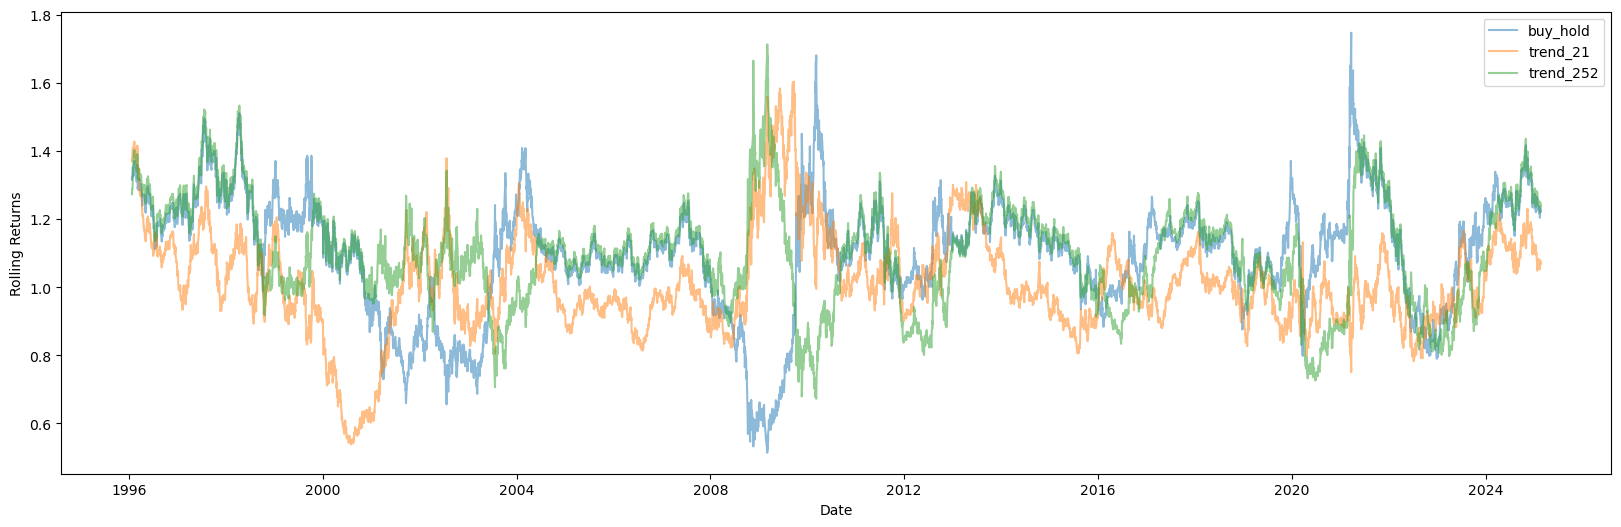

buy_hold
CAGR:           8.20%
Volatility:     19.31%
Sharpe Ratio:   0.42
--------------------------------------------
trend_21
CAGR:           -0.33%
Volatility:     18.98%
Sharpe Ratio:   -0.02
--------------------------------------------
trend_252
CAGR:           8.50%
Volatility:     19.24%
Sharpe Ratio:   0.44
--------------------------------------------


In [71]:
from strategies.trend_following import TrendFollowingStrategy

cols = []
df_display = pd.DataFrame()
def compare_returns(df_returns=None, col_name=None, plot=False):
    if col_name is not None:
        if col_name not in cols:
            cols.append(col_name)
        df_display[col_name] = df_returns['returns'].copy() + 1
        df_display[f'{col_name}_cum'] = df_display[col_name].cumprod()
        df_display[f'{col_name}_rolling'] = df_display[col_name].rolling(252).apply(lambda x: x.prod())

        df_display.dropna(inplace=True)
        for col in cols:
            df_display[f'{col}_cum'] = df_display[f'{col}_cum'] / df_display[f'{col}_cum'].iloc[0]

    if plot:
        plt.figure(figsize=(20, 6))
        for col in cols:
            plt.plot(df_display[f'{col}_cum'], label=col)
        plt.legend()
        plt.yscale('log')
        plt.xlabel('Date')
        plt.ylabel('Cumulative Returns')
        plt.show()

        plt.figure(figsize=(20, 6))
        for col in cols:
            plt.plot(df_display[f'{col}_rolling'], label=col, alpha=0.5)
        plt.legend()
        plt.xlabel('Date')
        plt.ylabel('Rolling Returns')
        plt.show()

        for col in cols:
            cagr = (df_display[f'{col}_cum'].iloc[-1] / df_display[f'{col}_cum'].iloc[0]) ** (252 / len(df_display)) - 1
            vol = df_display[f'{col}'].std() * np.sqrt(252)
            sr = cagr / vol

            print(col.replace('returns_', ''))
            print(f'CAGR:           {cagr:.2%}')
            print(f'Volatility:     {vol:.2%}')
            print(f'Sharpe Ratio:   {sr:.2f}')
            print('--------------------------------------------')
    

compare_returns(df_data[['returns']], 'buy_hold')

    



periods = [21, 252]
for period in periods:
    # Initialize backtester
    btr = BackTester({'SPY': df_data})
    # Add strategy
    btr.add_strategy(TrendFollowingStrategy, tickers=['SPY'], price_data={'SPY': df_data}, rebalance_period=5, lookback_period=period)
    results = btr.backtest()

    returns = results['returns'].copy()
    compare_returns(df_returns=results, col_name=f'trend_{period}')

compare_returns(plot=True)

#### Analysis

We note that lookback=252 seems to outperform both buy hold and lookback=21. Looking at the rolling returns, we see that there are periods where lookback=252, lookback=21, and buy-hold perform better than the other options. Instead of trying to optimize the lookback period, which is subject to overfitting concerns, we can instead try to dynamically adjust the lookback period based on market regime.

Our hypothesis here is that when the market is more volatile, we should use a shorter lookback period to allow the model to respond more quickly to market movements. Conversely, when the market is less volatile, we should use a longer lookback period to allow the model to capture longer-term trends and not be subject to noise or whip-saws.

Instead of just dynamically changing the lookback period, we should assign weights to the lookback periods and change those weights based on market regime.

## Split by Forward Volatility Thresholding

In [50]:
import backtrader as bt
from strategies.base import BaseStrategy

class VolSplitTrendStrategy(BaseStrategy):
    """Trend following strategy with configurable lookback period"""
    
    params = (
        ('high_vol_weights', {
            21  : 0.8, 
            252 : 0.2,
        }),
        ('low_vol_weights', {
            21  : 0.2, 
            252 : 0.8,
        }),  
        ('rebalance_period', 21),  # Rebalance period in days
        ('vol_threshold', 0.1),
        ('df_vol', pd.DataFrame()),
    )

    def __init__(self):
        super().__init__()
        
        # Indicator to track the trend via lagged returns
        self.returns = {}
        for key in self.p.high_vol_weights:
            self.returns[key] = bt.indicators.PercentChange(self.data.close, period=key)
        for key in self.p.low_vol_weights:
            if key not in self.returns:
                self.returns[key] = bt.indicators.PercentChange(self.data.close, period=key)
        
        # Weights for each lookback period
        self.weights = None

        # Rebalance period
        self.rebalance_day = 0

        # Forward vol prediction
        self.df_vol = self.p.df_vol

        
    def next(self):
        super().next()

        # On rebalance day, calculate the target position and submit the order
        if self.rebalance_day % self.p.rebalance_period == 0:
            target_position = self.calculate_position() * (self.broker.getvalue() / self.data.close[0])
            current_position = self.getposition(self.data).size
            self._submit_order(self.data._name, target_position - current_position, self.data.close[0])
        self.rebalance_day += 1

    
    def calculate_position(self):
        # Get current forward volatility prediction
        current_date = self.datetime.date()
        volatility = self.df_vol.loc[self.df_vol.index == pd.to_datetime(current_date), 'vol_forward_pred'].values[0]

        # if volatility > threshold, use high vol weights, else use low vol weights
        if volatility > self.p.vol_threshold:
            self.weights = self.p.high_vol_weights
        else:
            self.weights = self.p.low_vol_weights
        
        # Target position = sum of weights * direction
        target_position = 0
        for key in self.weights:
            direction = 1 if self.returns[key][0] > 0 else -1
            target_position += self.weights[key] * direction
        return target_position


### Reference

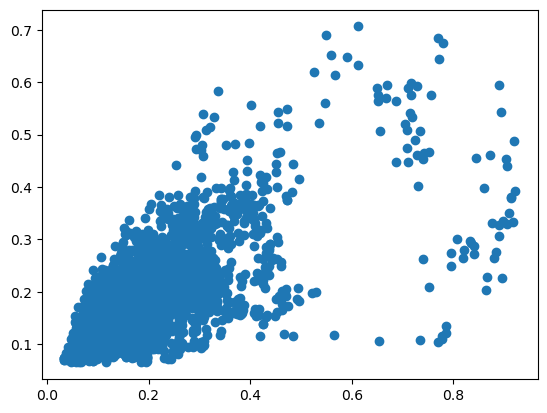

['cagr: 0.015388109238984038', 'volatility: 0.16479019394182187', 'sharpe: 0.09338000563563091', 'max_drawdown: 0.4346297914524144', 'cumulative_returns: 0.6060245429938402']


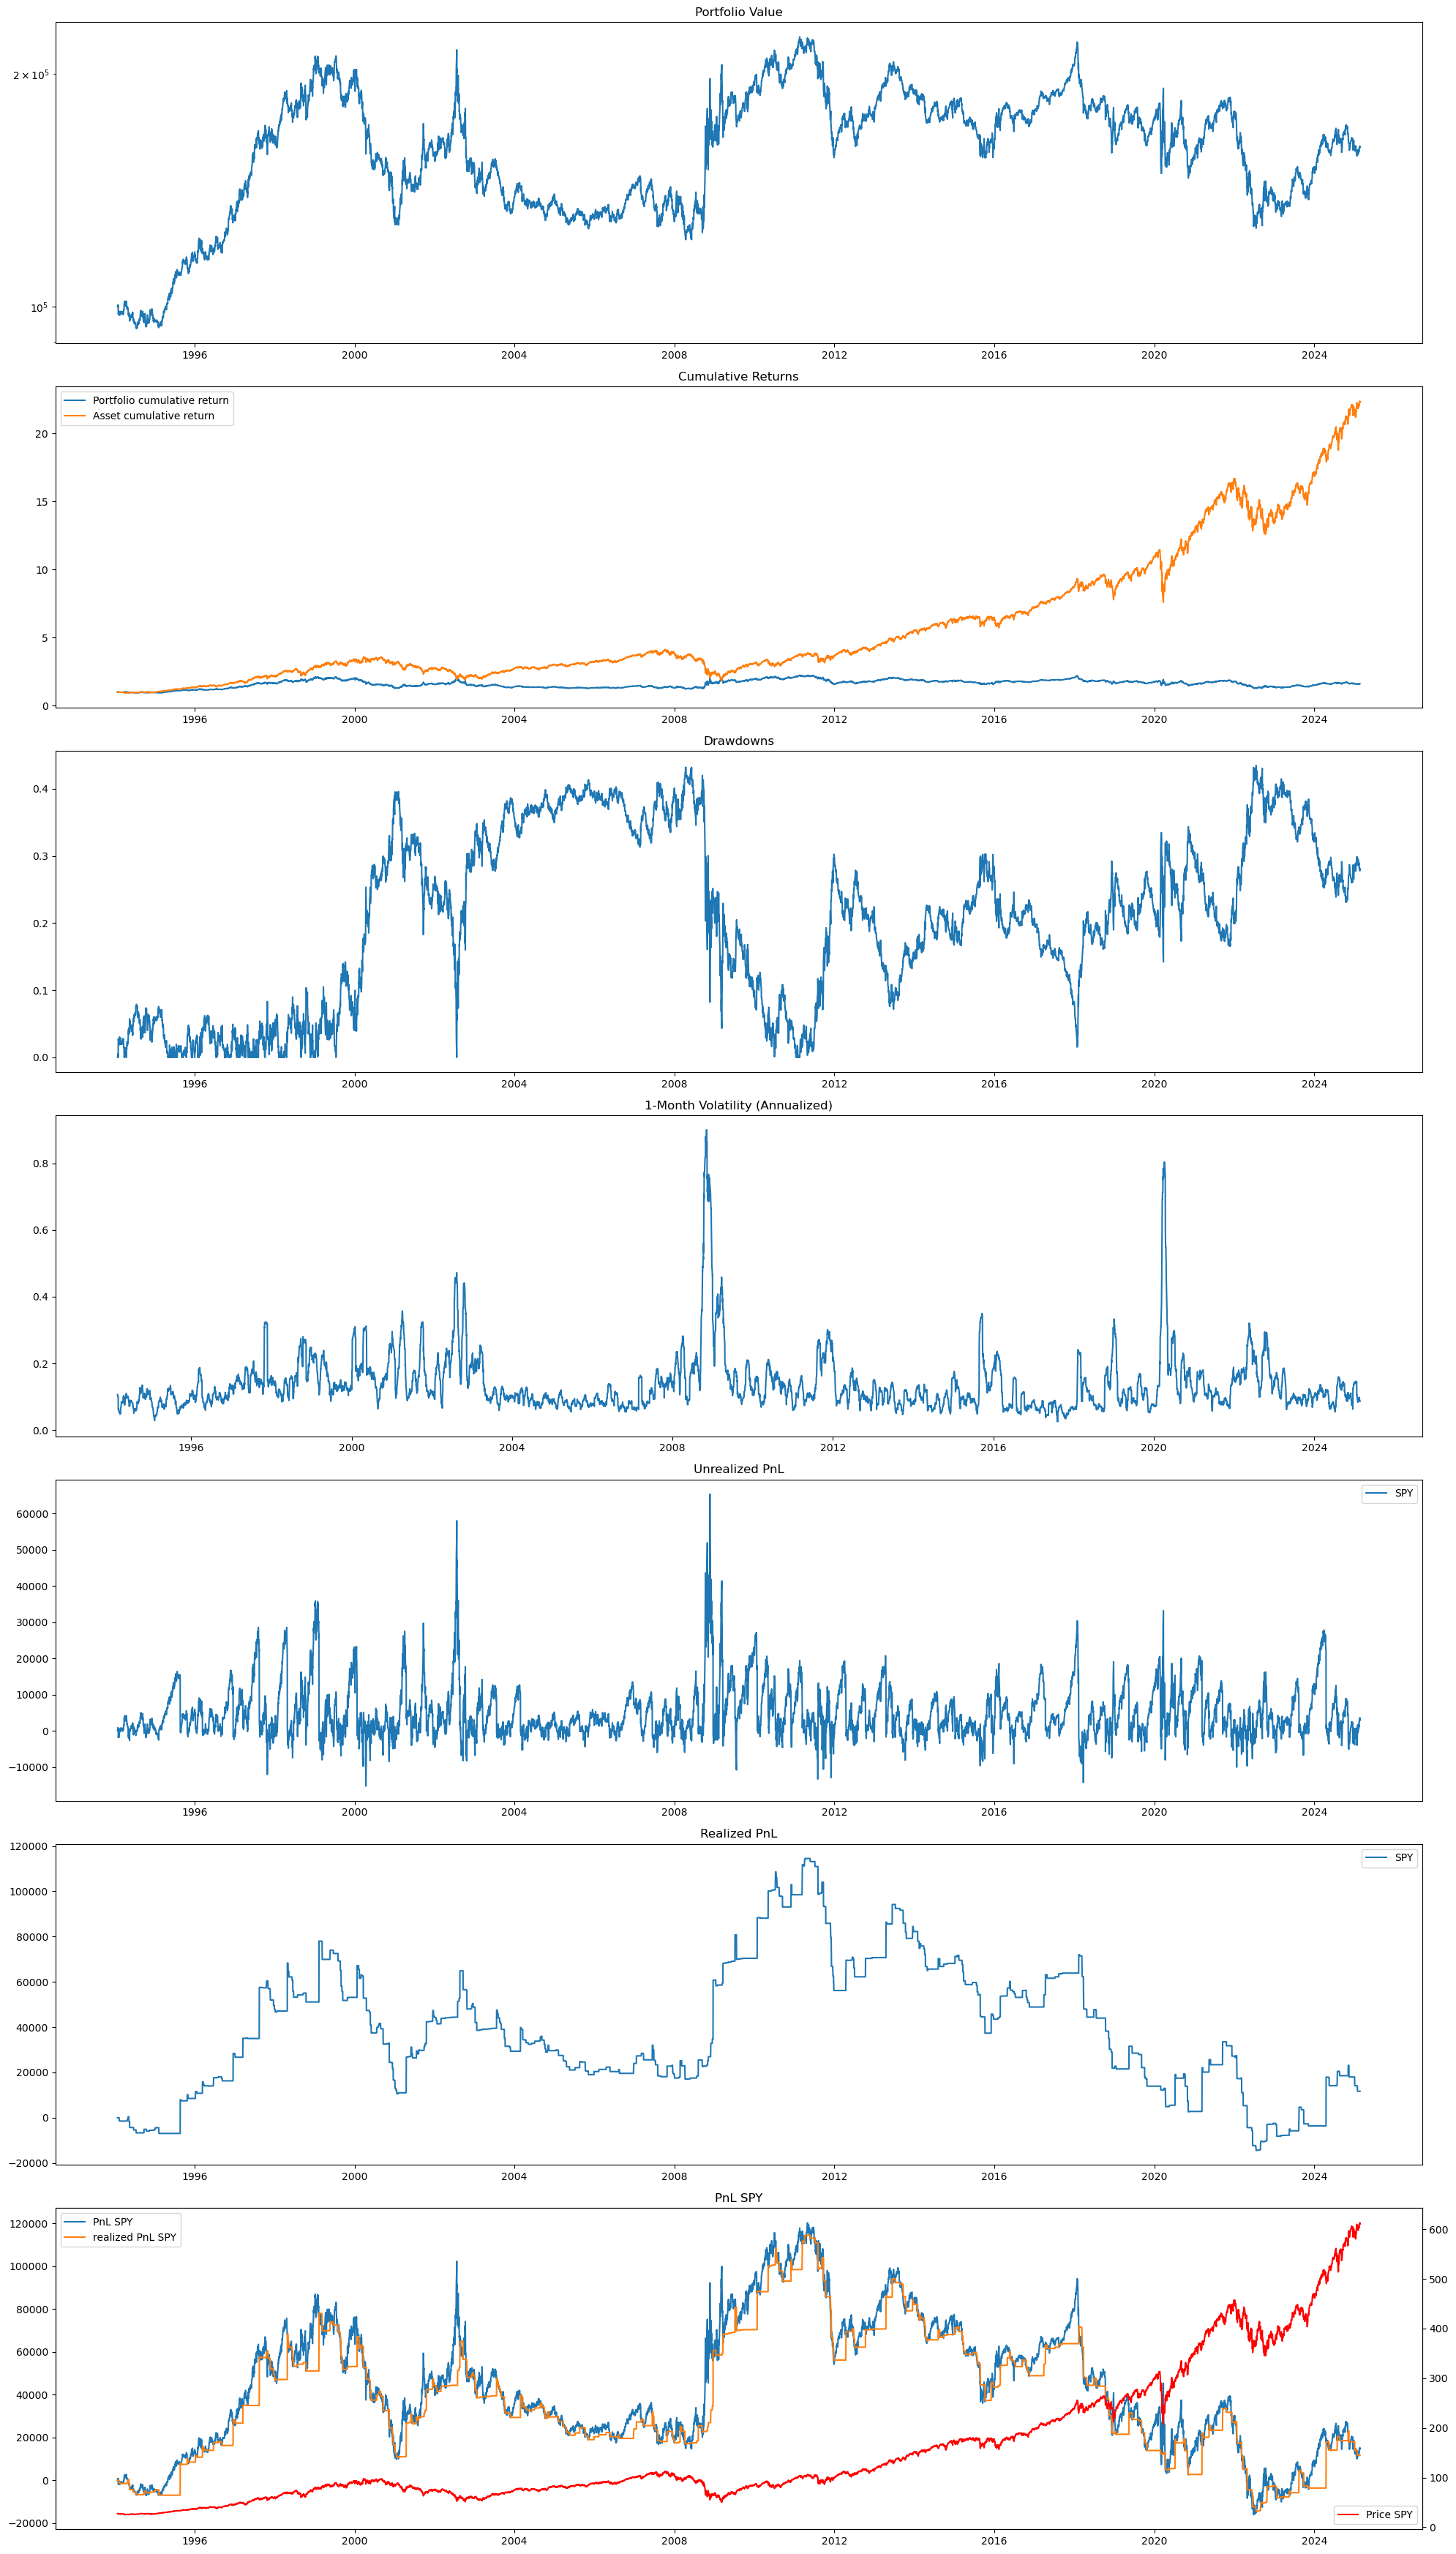

In [51]:
model = LinearRegression()
model.fit(df_data['vix'].values.reshape(-1, 1), df_data['vol_forward'].values.reshape(-1, 1))

df_data['vol_forward_pred'] = model.predict(df_data['vix'].values.reshape(-1, 1))
plt.scatter(df_data['vol_forward'], df_data['vol_forward_pred'])
plt.show()


# Initialize backtester
btr = BackTester({'SPY': df_data})
# Add strategy
btr.add_strategy(VolSplitTrendStrategy, tickers=['SPY'], price_data={'SPY': df_data}, rebalance_period=5, df_vol=df_data, vol_threshold=0.1)
results = btr.backtest()
print([f'{key}: {results[key]}' for key in results if key != 'returns'])
btr.plot_results()

### Optuna Optimization

In [52]:
import optuna
# use optuna to optimize the parameters of the strategy



def objective(trial):
    # Define the parameters to optimize
    rebalance_period = 5
    vol_threshold = trial.suggest_float('vol_threshold', 0.0, 1.0)
    high_vol_weights = {
        21: trial.suggest_float('high_vol_weights_21', 0.0, 1.0),
        252: trial.suggest_float('high_vol_weights_252', 0.0, 1.0),
    }
    
    low_vol_weights = {
        21: trial.suggest_float('low_vol_weights_21', 0.0, 1.0),
        252: trial.suggest_float('low_vol_weights_252', 0.0, 1.0),
    }

    # Normalize the weights so they sum to 1
    for key in high_vol_weights:
        high_vol_weights[key] = high_vol_weights[key] / sum(high_vol_weights.values())
    for key in low_vol_weights:
        low_vol_weights[key] = low_vol_weights[key] / sum(low_vol_weights.values())

    # Initialize backtester
    btr = BackTester({'SPY': df_data})
    # Add strategy
    btr.add_strategy(
        VolSplitTrendStrategy, 
        tickers=['SPY'], 
        price_data={'SPY': df_data}, 
        rebalance_period=rebalance_period, 
        df_vol=df_data, 
        vol_threshold=vol_threshold,
        high_vol_weights=high_vol_weights,
        low_vol_weights=low_vol_weights,
    )
    results = btr.backtest()
    return results['cagr']

# Create a study and optimize the objective function
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=100, show_progress_bar=True)

# Print the best parameters
print(f"Best parameters: {study.best_params}")
print(f"Best sharpe ratio: {study.best_value}")





[I 2025-03-30 15:40:04,783] A new study created in memory with name: no-name-293a1e7b-9070-4d0d-b401-7154902c308e


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2025-03-30 15:40:09,335] Trial 0 finished with value: 0.03859529761575642 and parameters: {'vol_threshold': 0.01822830989644575, 'high_vol_weights_21': 0.6807053257953967, 'high_vol_weights_252': 0.4765705389675906, 'low_vol_weights_21': 0.14693158483103108, 'low_vol_weights_252': 0.39475294162590713}. Best is trial 0 with value: 0.03859529761575642.
[I 2025-03-30 15:40:13,750] Trial 1 finished with value: 0.05013049087584842 and parameters: {'vol_threshold': 0.9899769573051215, 'high_vol_weights_21': 0.7430703863074176, 'high_vol_weights_252': 0.8861206485435419, 'low_vol_weights_21': 0.1832550132780747, 'low_vol_weights_252': 0.41823473100754904}. Best is trial 1 with value: 0.05013049087584842.
[I 2025-03-30 15:40:18,470] Trial 2 finished with value: 0.03989880886856989 and parameters: {'vol_threshold': 0.4706641338398163, 'high_vol_weights_21': 0.5259382605167711, 'high_vol_weights_252': 0.2376912845146829, 'low_vol_weights_21': 0.9248654317651253, 'low_vol_weights_252': 0.54458

high_vol_weights {21: 0.557868562103713, 252: 0.5293174250619178}
low_vol_weights {21: 0.0001762197908453176, 252: 0.9997659533340759}
['cagr: 0.08', 'volatility: 0.19', 'sharpe: 0.42', 'max_drawdown: 0.39', 'cumulative_returns: 9.75']


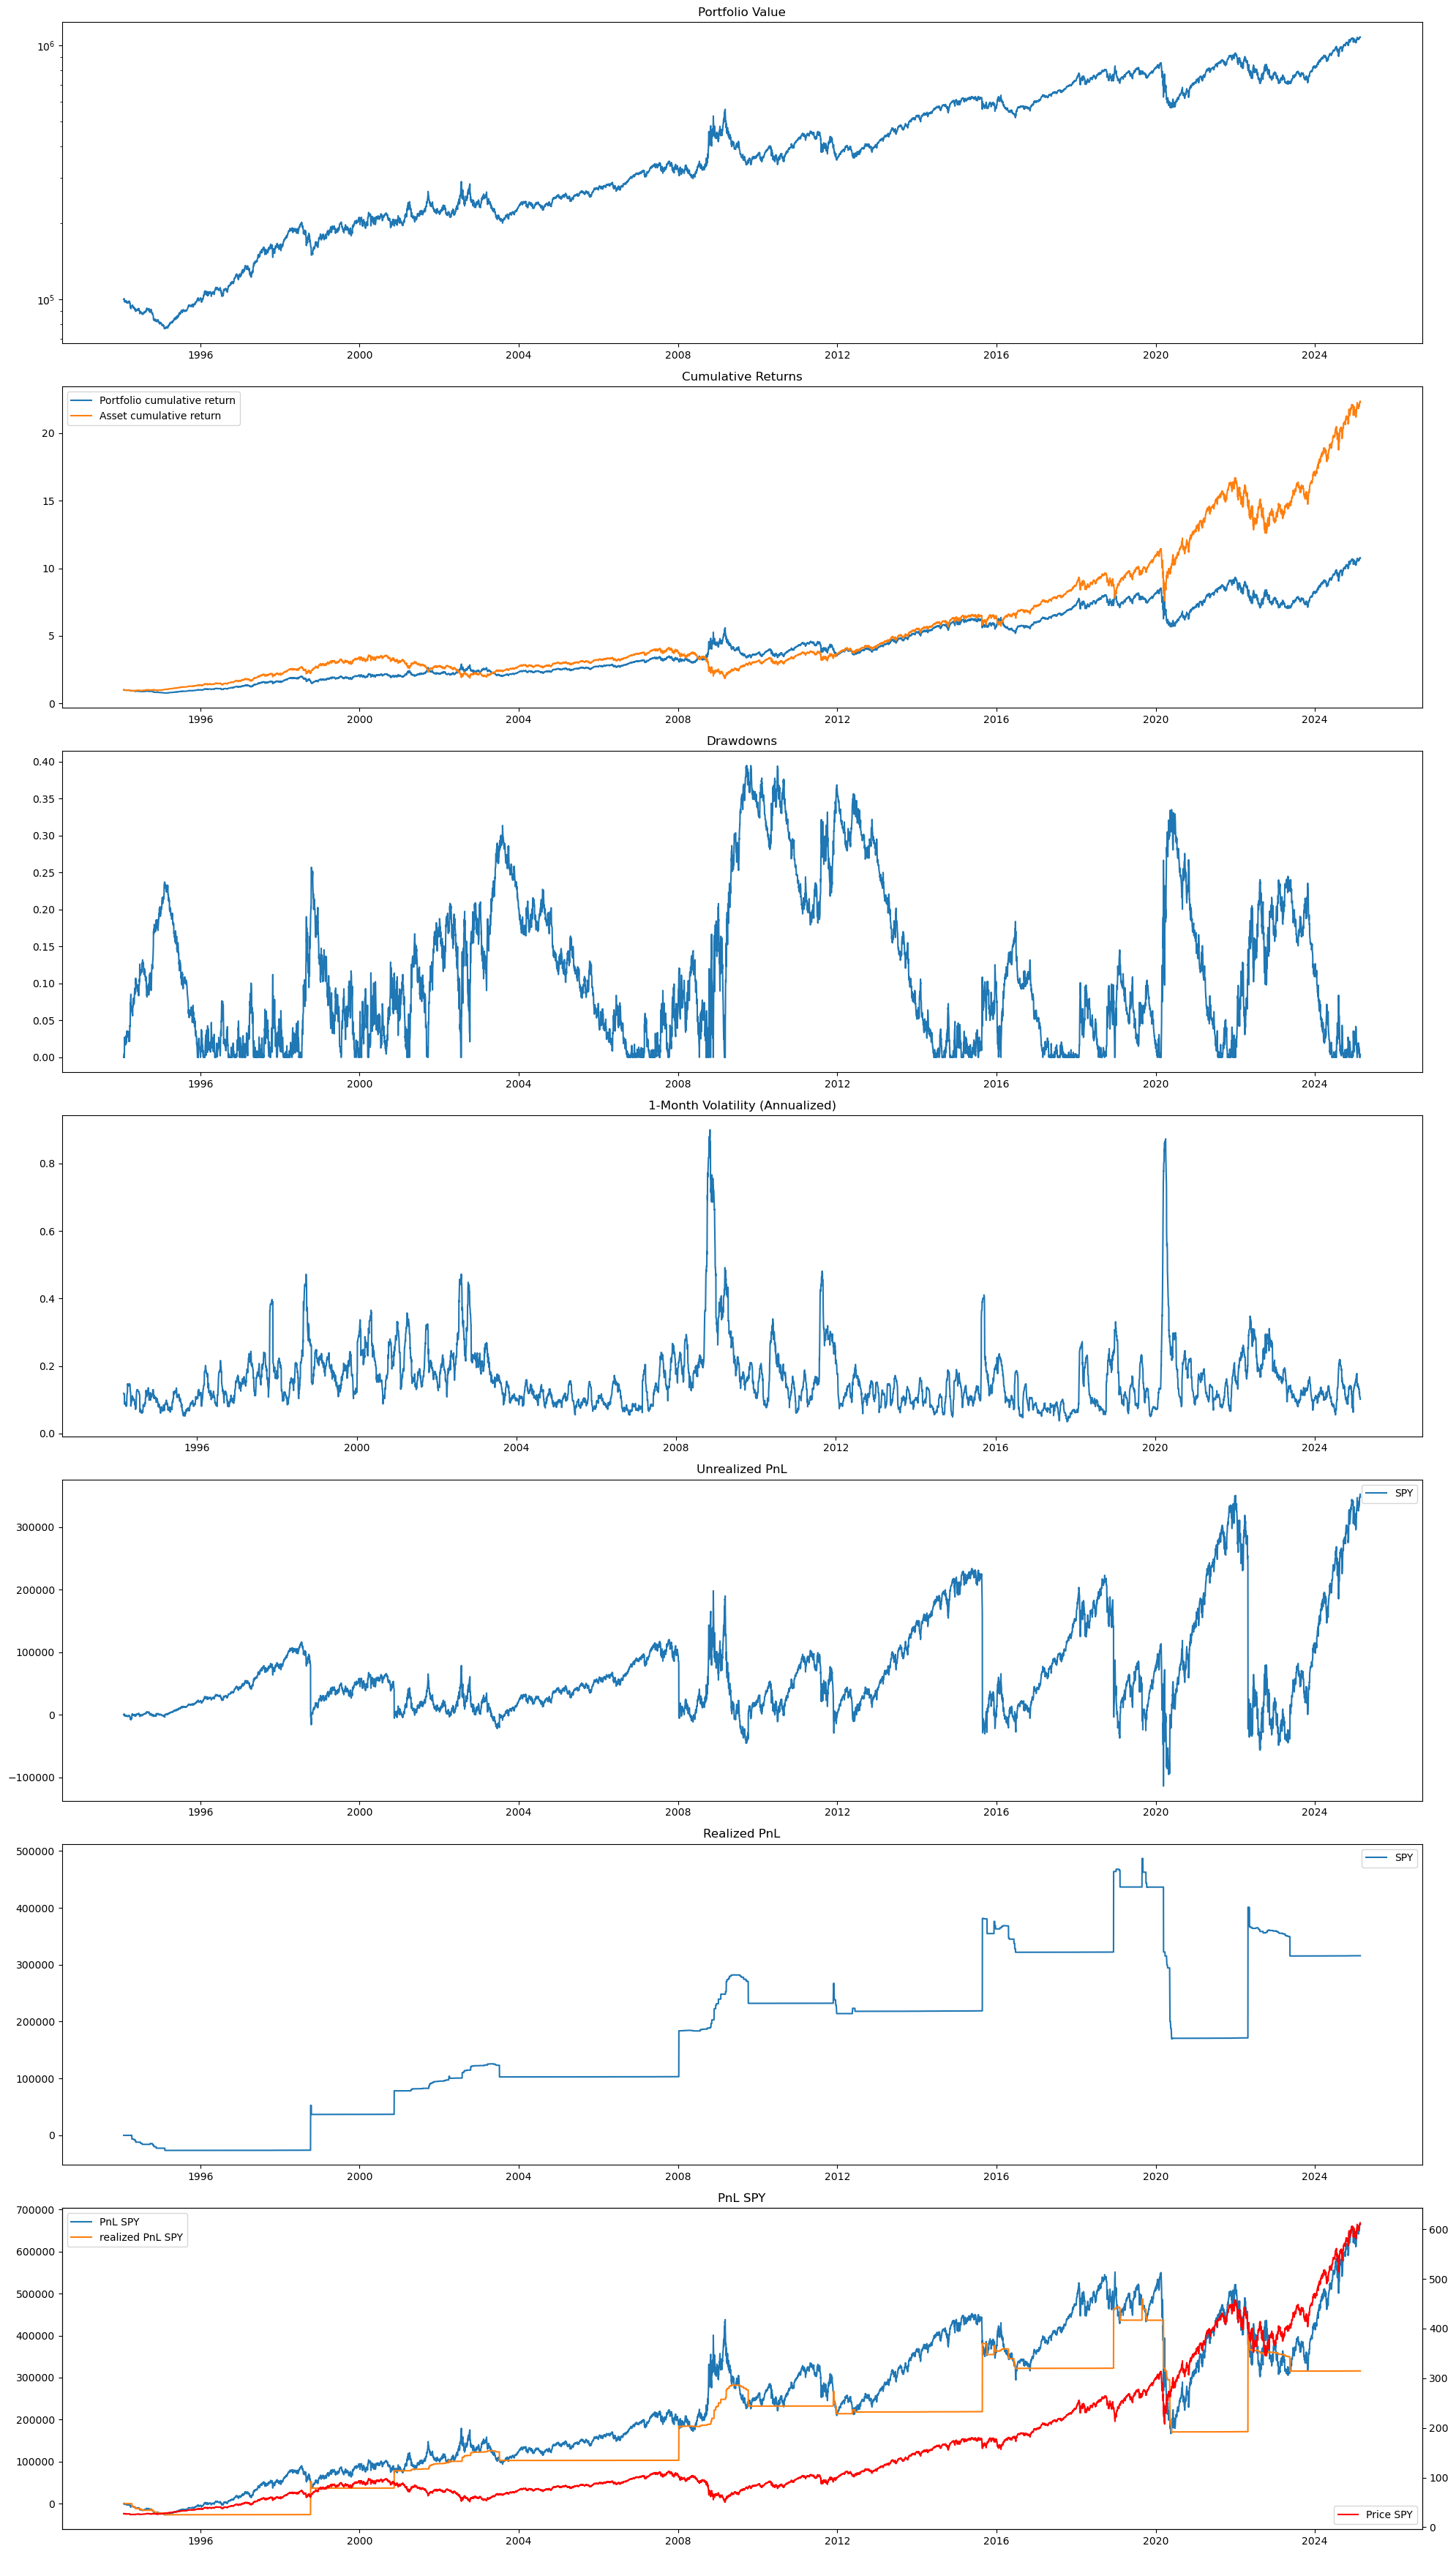

In [53]:
opt_high_vol_weights = {
    21: study.best_params['high_vol_weights_21'],
    252: study.best_params['high_vol_weights_252'],
}
opt_low_vol_weights = {
    21: study.best_params['low_vol_weights_21'],
    252: study.best_params['low_vol_weights_252'],
}
for key in opt_high_vol_weights:
    opt_high_vol_weights[key] = opt_high_vol_weights[key] / sum(opt_high_vol_weights.values())

for key in opt_low_vol_weights:
    opt_low_vol_weights[key] = opt_low_vol_weights[key] / sum(opt_low_vol_weights.values())

print('high_vol_weights', opt_high_vol_weights)
print('low_vol_weights', opt_low_vol_weights)


# Initialize backtester
btr = BackTester({'SPY': df_data})
# Add strategy
btr.add_strategy(
    VolSplitTrendStrategy, 
    tickers=['SPY'], 
    price_data={'SPY': df_data}, 
    rebalance_period=5, 
    df_vol=df_data, 
    vol_threshold=study.best_params['vol_threshold'],
    high_vol_weights=opt_high_vol_weights,
    low_vol_weights=opt_low_vol_weights,
)
results = btr.backtest()
print([f'{key}: {value:.2f}' for key, value in results.items() if key != 'returns'])
btr.plot_results()

### Comparison

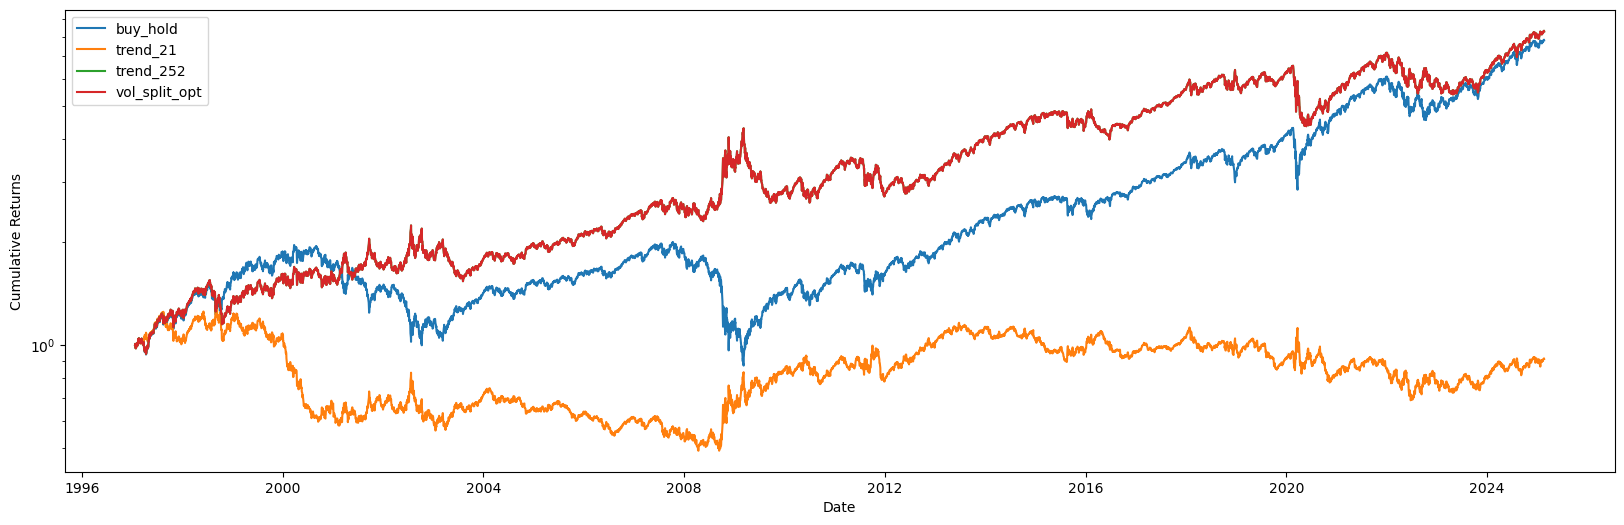

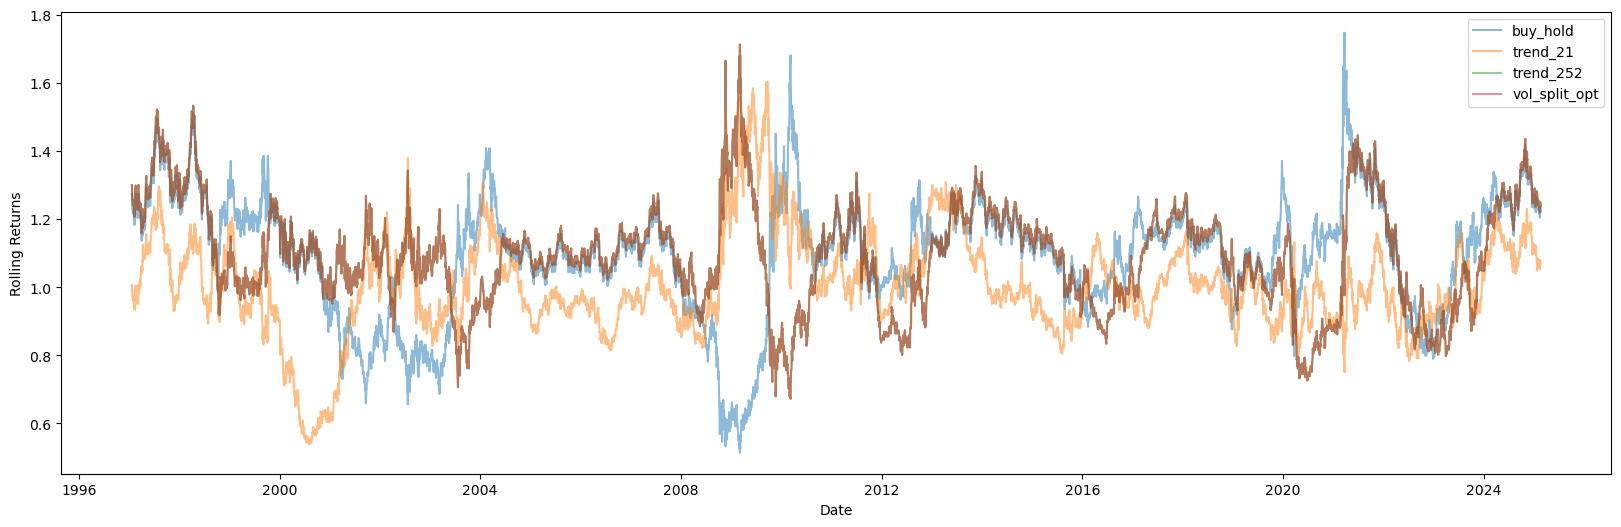

buy_hold
CAGR:           7.60%
Volatility:     19.50%
Sharpe Ratio:   0.39
--------------------------------------------
trend_21
CAGR:           -0.34%
Volatility:     19.15%
Sharpe Ratio:   -0.02
--------------------------------------------
trend_252
CAGR:           7.83%
Volatility:     19.42%
Sharpe Ratio:   0.40
--------------------------------------------
vol_split_opt
CAGR:           7.83%
Volatility:     19.41%
Sharpe Ratio:   0.40
--------------------------------------------


In [54]:
compare_returns(df_returns=results['returns'], col_name="vol_split_opt", plot=True)


## Vol Reduction

In [55]:
import backtrader as bt
from strategies.base import BaseStrategy

class VolReductionTrendStrategy(BaseStrategy):
    """Trend following strategy with configurable lookback period"""
    
    params = (
        ('lookback_period', 252),
        ('rebalance_period', 21),  # Rebalance period in days
        ('vol_threshold', 0.1),
        ('df_vol', pd.DataFrame()),
        ('vol_reduction_factor', 0.5),
    )

    def __init__(self):
        super().__init__()
        
        # Indicator to track the trend via lagged returns
        self.returns = bt.indicators.PercentChange(self.data.close, period=self.p.lookback_period)

        # Rebalance period
        self.rebalance_day = 0

        # Forward vol prediction
        self.df_vol = self.p.df_vol

        
    def next(self):
        super().next()

        # On rebalance day, calculate the target position and submit the order
        if self.rebalance_day % self.p.rebalance_period == 0:
            target_position = self.calculate_position() * (self.broker.getvalue() / self.data.close[0])
            current_position = self.getposition(self.data).size
            self._submit_order(self.data._name, target_position - current_position, self.data.close[0])
        self.rebalance_day += 1

    
    def calculate_position(self):
        # Get current forward volatility prediction
        current_date = self.datetime.date()
        volatility = self.df_vol.loc[self.df_vol.index == pd.to_datetime(current_date), 'vol_forward_pred'].values[0]
        target_position = 0
        if self.returns[0] > 0:
            target_position = 1
        else:
            target_position = -1
        
        # if volatility > threshold, reduce position size
        if volatility > self.p.vol_threshold:
            target_position *= self.p.vol_reduction_factor
        

        

        return target_position


### Reference

,open,high,low,close,adjclose,volume,dividends,stock_splits,capital_gains,returns,vol_forward,vix,vol_forward_pred
Date,,,,,,,,,,,,,
1993-02-01,43.96875,44.25000,43.96875,44.25000,24.700506,480500,0.0,0.0,0.0,0.007112,0.126257,12.33,0.092686
1993-02-02,44.21875,44.37500,44.12500,44.34375,24.752844,201300,0.0,0.0,0.0,0.002119,0.128059,12.25,0.091988
1993-02-03,44.40625,44.84375,44.37500,44.81250,25.014509,529400,0.0,0.0,0.0,0.010571,0.123457,12.12,0.090854
1993-02-04,44.96875,45.09375,44.46875,45.00000,25.119164,531500,0.0,0.0,0.0,0.004184,0.144399,12.29,0.092337
1993-02-05,44.96875,45.06250,44.71875,44.96875,25.101734,492100,0.0,0.0,0.0,-0.000694,0.145035,12.90,0.097660


['cagr: 0.05426785115648758', 'volatility: 0.09988245124387292', 'sharpe: 0.543317174144908', 'max_drawdown: 0.261433974059471', 'cumulative_returns: 4.15259864741704']


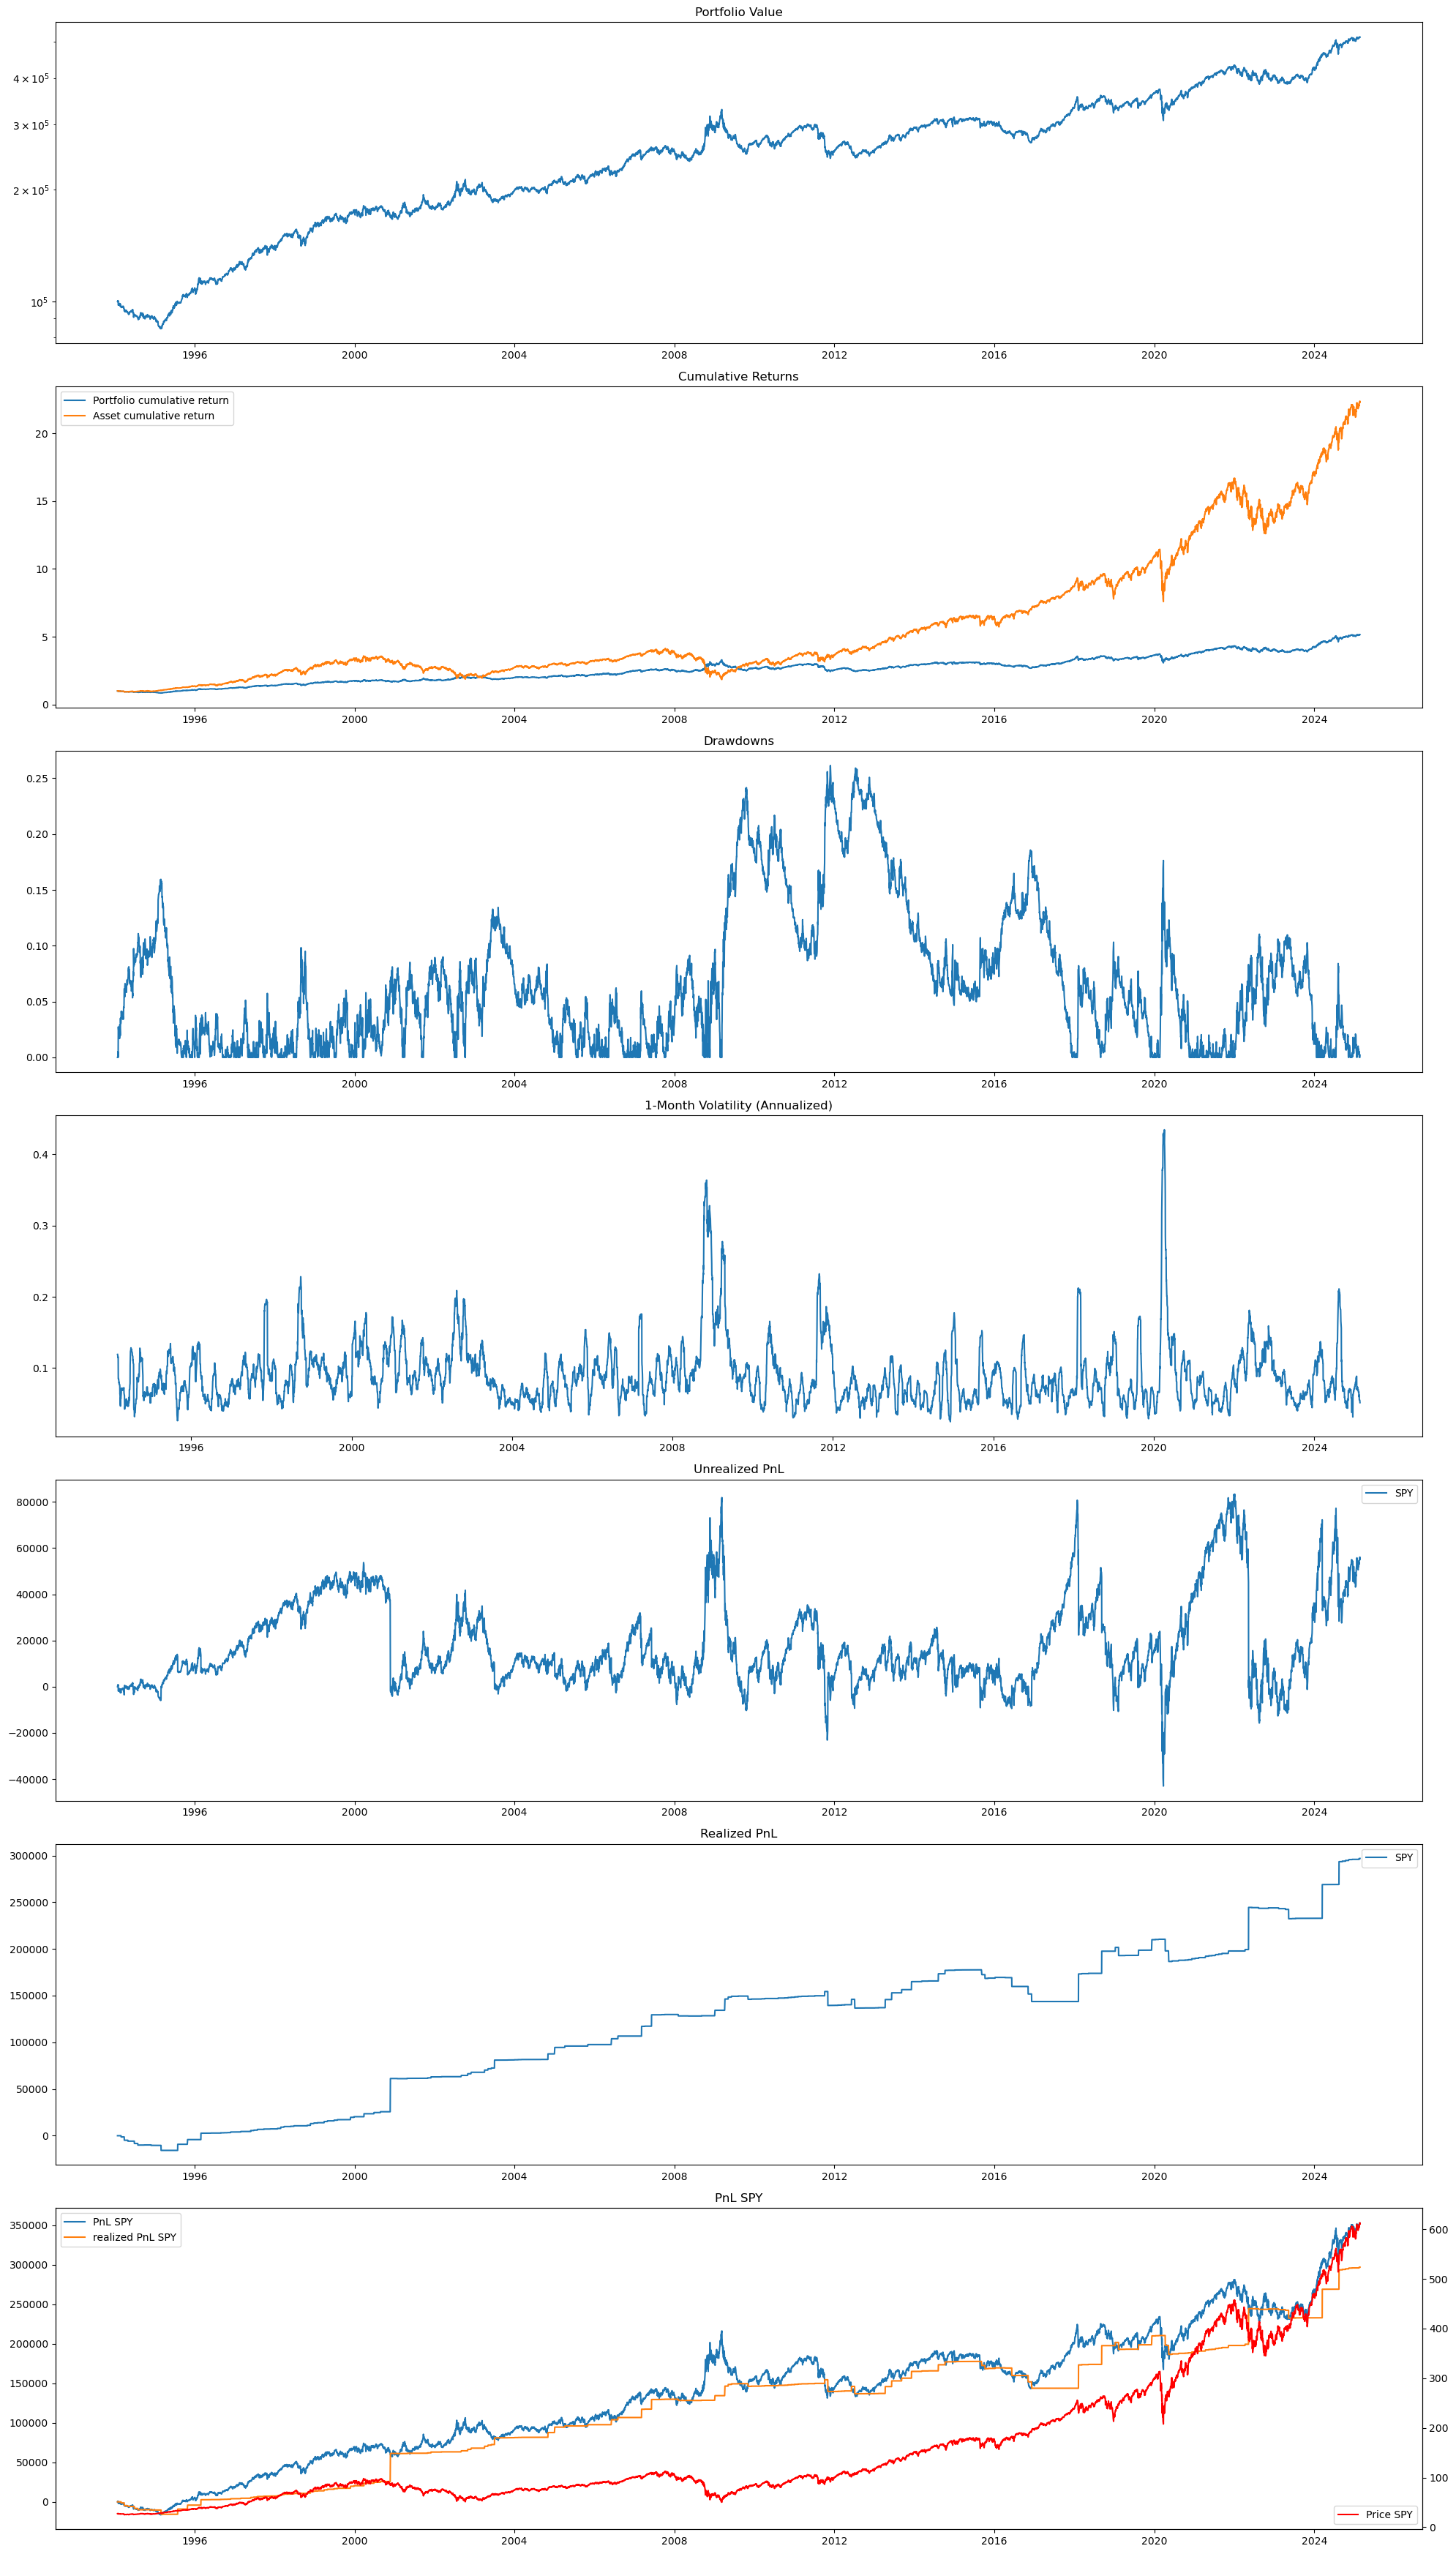

In [56]:
display(df_data.head())

# Initialize backtester
btr = BackTester({'SPY': df_data})
# Add strategy
btr.add_strategy(VolReductionTrendStrategy, tickers=['SPY'], price_data={'SPY': df_data}, rebalance_period=21, df_vol=df_data, vol_threshold=0.1, lookback_period=252, vol_reduction_factor=0.5)
results = btr.backtest()
print([f'{key}: {results[key]}' for key in results if key != 'returns'])
btr.plot_results()

### Optuna

In [72]:
import optuna
# use optuna to optimize the parameters of the strategy



def objective(trial):
    # Define the parameters to optimize
    rebalance_period = 5
    vol_threshold = trial.suggest_float('vol_threshold', 0.0, 1.0)
    vol_reduction_factor = trial.suggest_float('vol_reduction_factor', 0.0, 1.0)
    

    # Initialize backtester
    btr = BackTester({'SPY': df_data})
    # Add strategy
    btr.add_strategy(
        VolReductionTrendStrategy, 
        tickers=['SPY'], 
        price_data={'SPY': df_data}, 
        rebalance_period=rebalance_period, 
        df_vol=df_data, 
        vol_threshold=vol_threshold,
        lookback_period=252,
        vol_reduction_factor=vol_reduction_factor,
    )
    results = btr.backtest()
    return results['cagr']

# Create a study and optimize the objective function
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=100, show_progress_bar=True)

# Print the best parameters
print(f"Best parameters: {study.best_params}")
print(f"Best sharpe ratio: {study.best_value}")

[I 2025-03-30 16:16:45,767] A new study created in memory with name: no-name-685e8b64-8d46-4069-9715-ee14b239bc08


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2025-03-30 16:16:50,495] Trial 0 finished with value: 0.05426282619276579 and parameters: {'vol_threshold': 0.07334258786946635, 'vol_reduction_factor': 0.6375425418983431}. Best is trial 0 with value: 0.05426282619276579.
[I 2025-03-30 16:16:54,816] Trial 1 finished with value: 0.08617081722042719 and parameters: {'vol_threshold': 0.2936845303998964, 'vol_reduction_factor': 0.5030622159572729}. Best is trial 1 with value: 0.08617081722042719.
[I 2025-03-30 16:16:59,115] Trial 2 finished with value: 0.08115297906252938 and parameters: {'vol_threshold': 0.4248635804116657, 'vol_reduction_factor': 0.2928164002765845}. Best is trial 1 with value: 0.08617081722042719.
[I 2025-03-30 16:17:03,466] Trial 3 finished with value: 0.007173908654857231 and parameters: {'vol_threshold': 0.07579433635312494, 'vol_reduction_factor': 0.05842312650519632}. Best is trial 1 with value: 0.08617081722042719.
[I 2025-03-30 16:17:08,200] Trial 4 finished with value: 0.06926086673150089 and parameters: {'v

['cagr: 0.08823908780549816', 'volatility: 0.16625036912368593', 'sharpe: 0.5307602519658202', 'max_drawdown: 0.30066458245464694', 'cumulative_returns: 12.782510752878421']


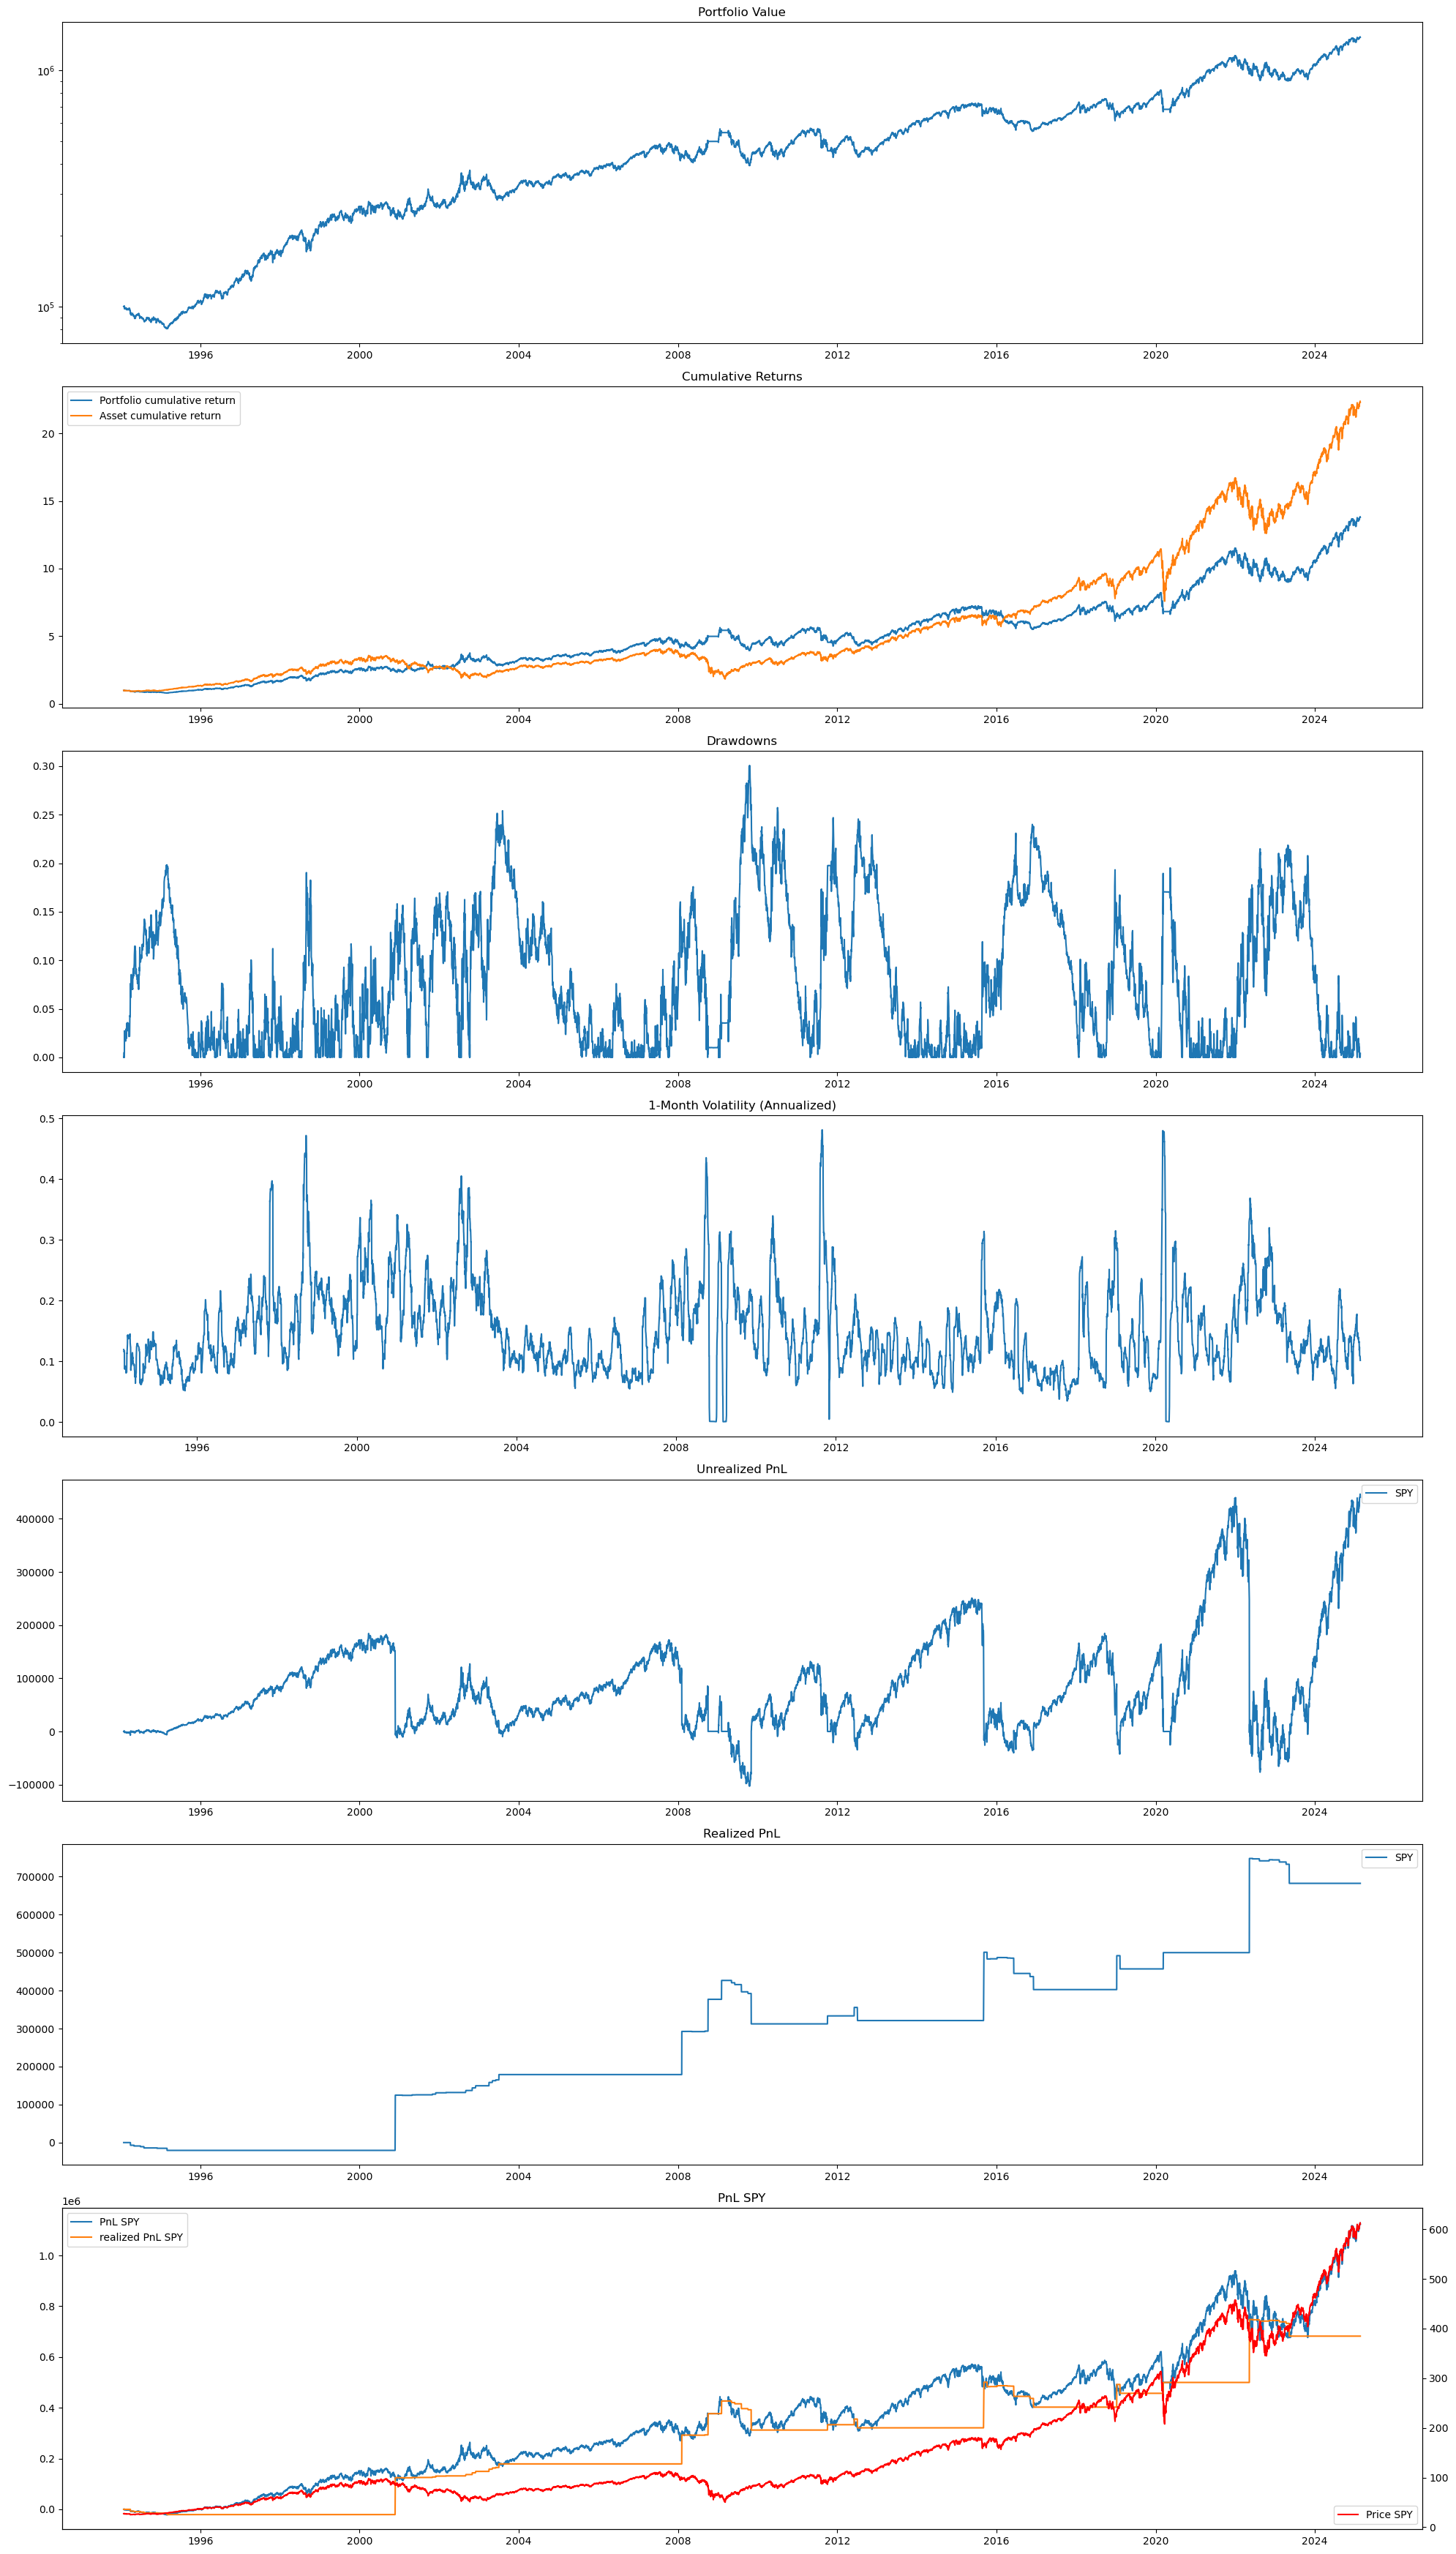

In [73]:
# Initialize backtester
btr = BackTester({'SPY': df_data})
# Add strategy
btr.add_strategy(
    VolReductionTrendStrategy, 
    tickers=['SPY'], 
    price_data={'SPY': df_data}, 
    rebalance_period=21, 
    df_vol=df_data, 
    vol_threshold=study.best_params['vol_threshold'], 
    lookback_period=252, 
    vol_reduction_factor=study.best_params['vol_reduction_factor'],
)
results = btr.backtest()
print([f'{key}: {results[key]}' for key in results if key != 'returns'])
btr.plot_results()

### Comparison

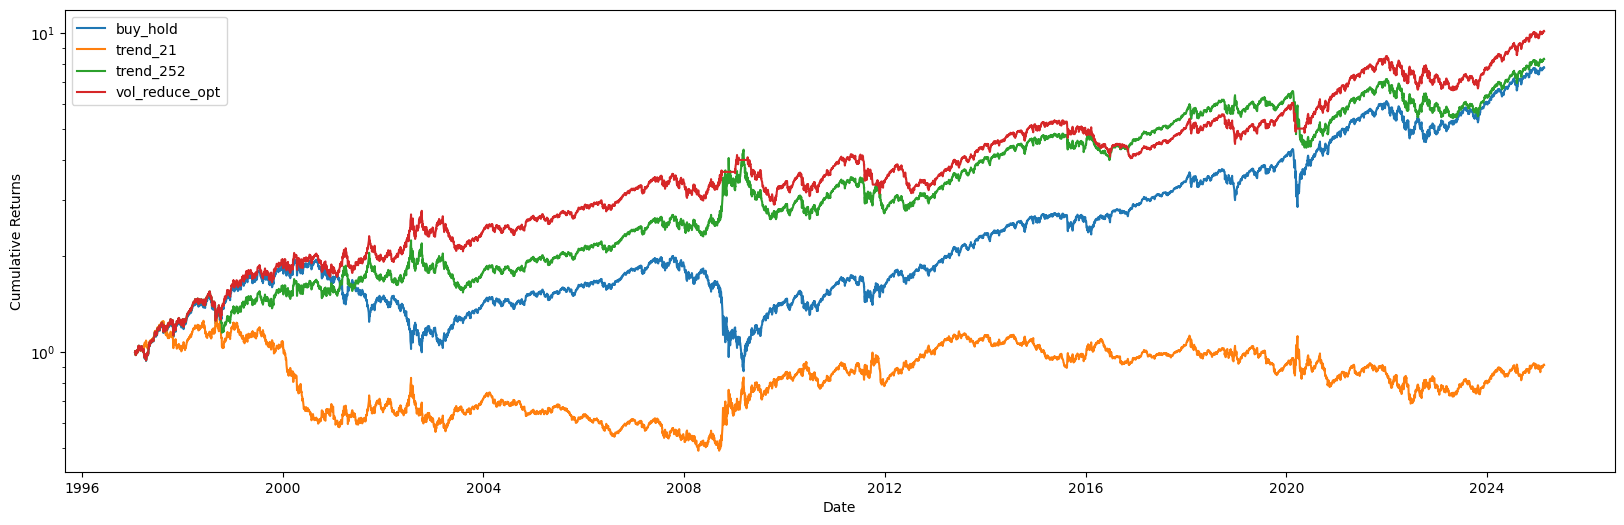

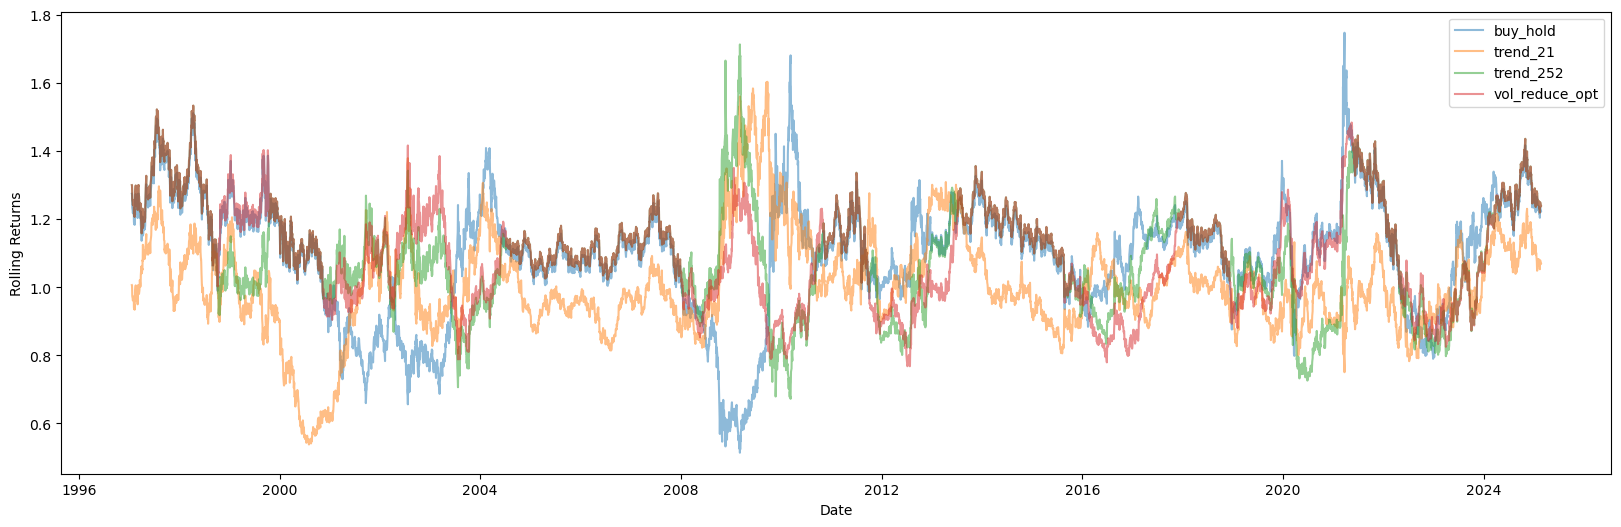

buy_hold
CAGR:           7.60%
Volatility:     19.50%
Sharpe Ratio:   0.39
--------------------------------------------
trend_21
CAGR:           -0.34%
Volatility:     19.15%
Sharpe Ratio:   -0.02
--------------------------------------------
trend_252
CAGR:           7.83%
Volatility:     19.42%
Sharpe Ratio:   0.40
--------------------------------------------
vol_reduce_opt
CAGR:           8.61%
Volatility:     17.10%
Sharpe Ratio:   0.50
--------------------------------------------


In [74]:
compare_returns(df_returns=results['returns'], col_name="vol_reduce_opt", plot=True)


## Split by Trend

In [9]:
from strategies.base import BaseStrategy
import backtrader as bt
class TrendSplitTrendStrategy(BaseStrategy):
    """Trend following strategy with configurable lookback period"""
    
    params = (
        ('correction_weights', {
            21  : 0.6, 
            252 : 0.4,
        }),
        ('rebound_weights', {
            21  : 0.6, 
            252 : 0.4,
        }),  
        ('rebalance_period', 21),  # Rebalance period in days
    )

    def __init__(self):
        super().__init__()
        
        # Indicator to track the trend via lagged returns
        self.returns = {}
        for key in self.p.correction_weights:
            self.returns[key] = bt.indicators.PercentChange(self.data.close, period=key)
        for key in self.p.rebound_weights:
            if key not in self.returns:
                self.returns[key] = bt.indicators.PercentChange(self.data.close, period=key)
        
        # Weights for each lookback period
        self.weights = None

        # Rebalance period
        self.rebalance_day = 0

        
    def next(self):
        super().next()

        # On rebalance day, calculate the target position and submit the order
        if self.rebalance_day % self.p.rebalance_period == 0:
            target_position = self.calculate_position() * (self.broker.getvalue() / self.data.close[0])
            current_position = self.getposition(self.data).size
            self._submit_order(self.data._name, target_position - current_position, self.data.close[0])
        self.rebalance_day += 1

    
    def calculate_position(self):
        
        
        if self.returns[21][0] > 0 and self.returns[252][0] < 0:
            self.weights = self.p.rebound_weights
        elif self.returns[21][0] < 0 and self.returns[252][0] > 0:
            self.weights = self.p.correction_weights
        else:
            self.weights = {
                21  : 0,
                252 : 1,
            }
        
        # Target position = sum of weights * direction
        target_position = 0
        for key in self.weights:
            direction = 1 if self.returns[key][0] > 0 else -1
            target_position += self.weights[key] * direction
        return target_position

### Reference

In [8]:
# Initialize backtester
btr = BackTester({'SPY': df_data})
# Add strategy
btr.add_strategy(TrendSplitTrendStrategy, tickers=['SPY'], price_data={'SPY': df_data}, rebalance_period=21)
results = btr.backtest()
print([f'{key}: {results[key]}' for key in results if key != 'returns'])
btr.plot_results()

NameError: name 'bt' is not defined

### Optuna

In [77]:
import optuna
# use optuna to optimize the parameters of the strategy



def objective(trial):
    # Define the parameters to optimize
    rebalance_period = 5
    
    correction_weights = {
        21: trial.suggest_float('correction_weights_21', 0.0, 1.0),
        252: trial.suggest_float('correction_weights_252', 0.0, 1.0),
    }
    
    rebound_weights = {
        21: trial.suggest_float('rebound_weights_21', 0.0, 1.0),
        252: trial.suggest_float('rebound_weights_252', 0.0, 1.0),
    }

    # Normalize the weights so they sum to 1
    s = sum(correction_weights.values())
    for key in correction_weights:
        correction_weights[key] = correction_weights[key] / s
    s = sum(rebound_weights.values())
    for key in rebound_weights:
        rebound_weights[key] = rebound_weights[key] / s

    # Initialize backtester
    btr = BackTester({'SPY': df_data})
    # Add strategy
    btr.add_strategy(
        TrendSplitTrendStrategy, 
        tickers=['SPY'], 
        price_data={'SPY': df_data}, 
        rebalance_period=rebalance_period, 
        correction_weights=correction_weights,
        rebound_weights=rebound_weights,
    )
    results = btr.backtest()
    return results['cagr']

# Create a study and optimize the objective function
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=100, show_progress_bar=True)

# Print the best parameters
print(f"Best parameters: {study.best_params}")
# print(f"Best sharpe ratio: {study.best_value}")
print(f"Best cagr: {study.best_value}")





[I 2025-03-30 16:24:30,826] A new study created in memory with name: no-name-7ee17e5f-5252-4dc2-96a0-858a944c17f4


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2025-03-30 16:24:35,019] Trial 0 finished with value: 0.05662089267819659 and parameters: {'correction_weights_21': 0.4558646859312254, 'correction_weights_252': 0.4755489589435059, 'rebound_weights_21': 0.35663167422578046, 'rebound_weights_252': 0.00909771356172906}. Best is trial 0 with value: 0.05662089267819659.
[I 2025-03-30 16:24:39,155] Trial 1 finished with value: 0.06181613869097813 and parameters: {'correction_weights_21': 0.6935870728928479, 'correction_weights_252': 0.9287012117482297, 'rebound_weights_21': 0.379510424745638, 'rebound_weights_252': 0.04069923045055046}. Best is trial 1 with value: 0.06181613869097813.
[I 2025-03-30 16:24:43,538] Trial 2 finished with value: 0.022018581701752638 and parameters: {'correction_weights_21': 0.4262522466295835, 'correction_weights_252': 0.2386313350298247, 'rebound_weights_21': 0.2230520539886779, 'rebound_weights_252': 0.6781777771670153}. Best is trial 1 with value: 0.06181613869097813.
[I 2025-03-30 16:24:47,679] Trial 3 f

correction {21: 0.0, 252: 1.0}
rebound {21: 0.7, 252: 0.3}
['cagr: 0.09900526222341877', 'volatility: 0.17881510271924164', 'sharpe: 0.5536739387101287', 'max_drawdown: 0.3289669358971746', 'cumulative_returns: 17.740561613892094']


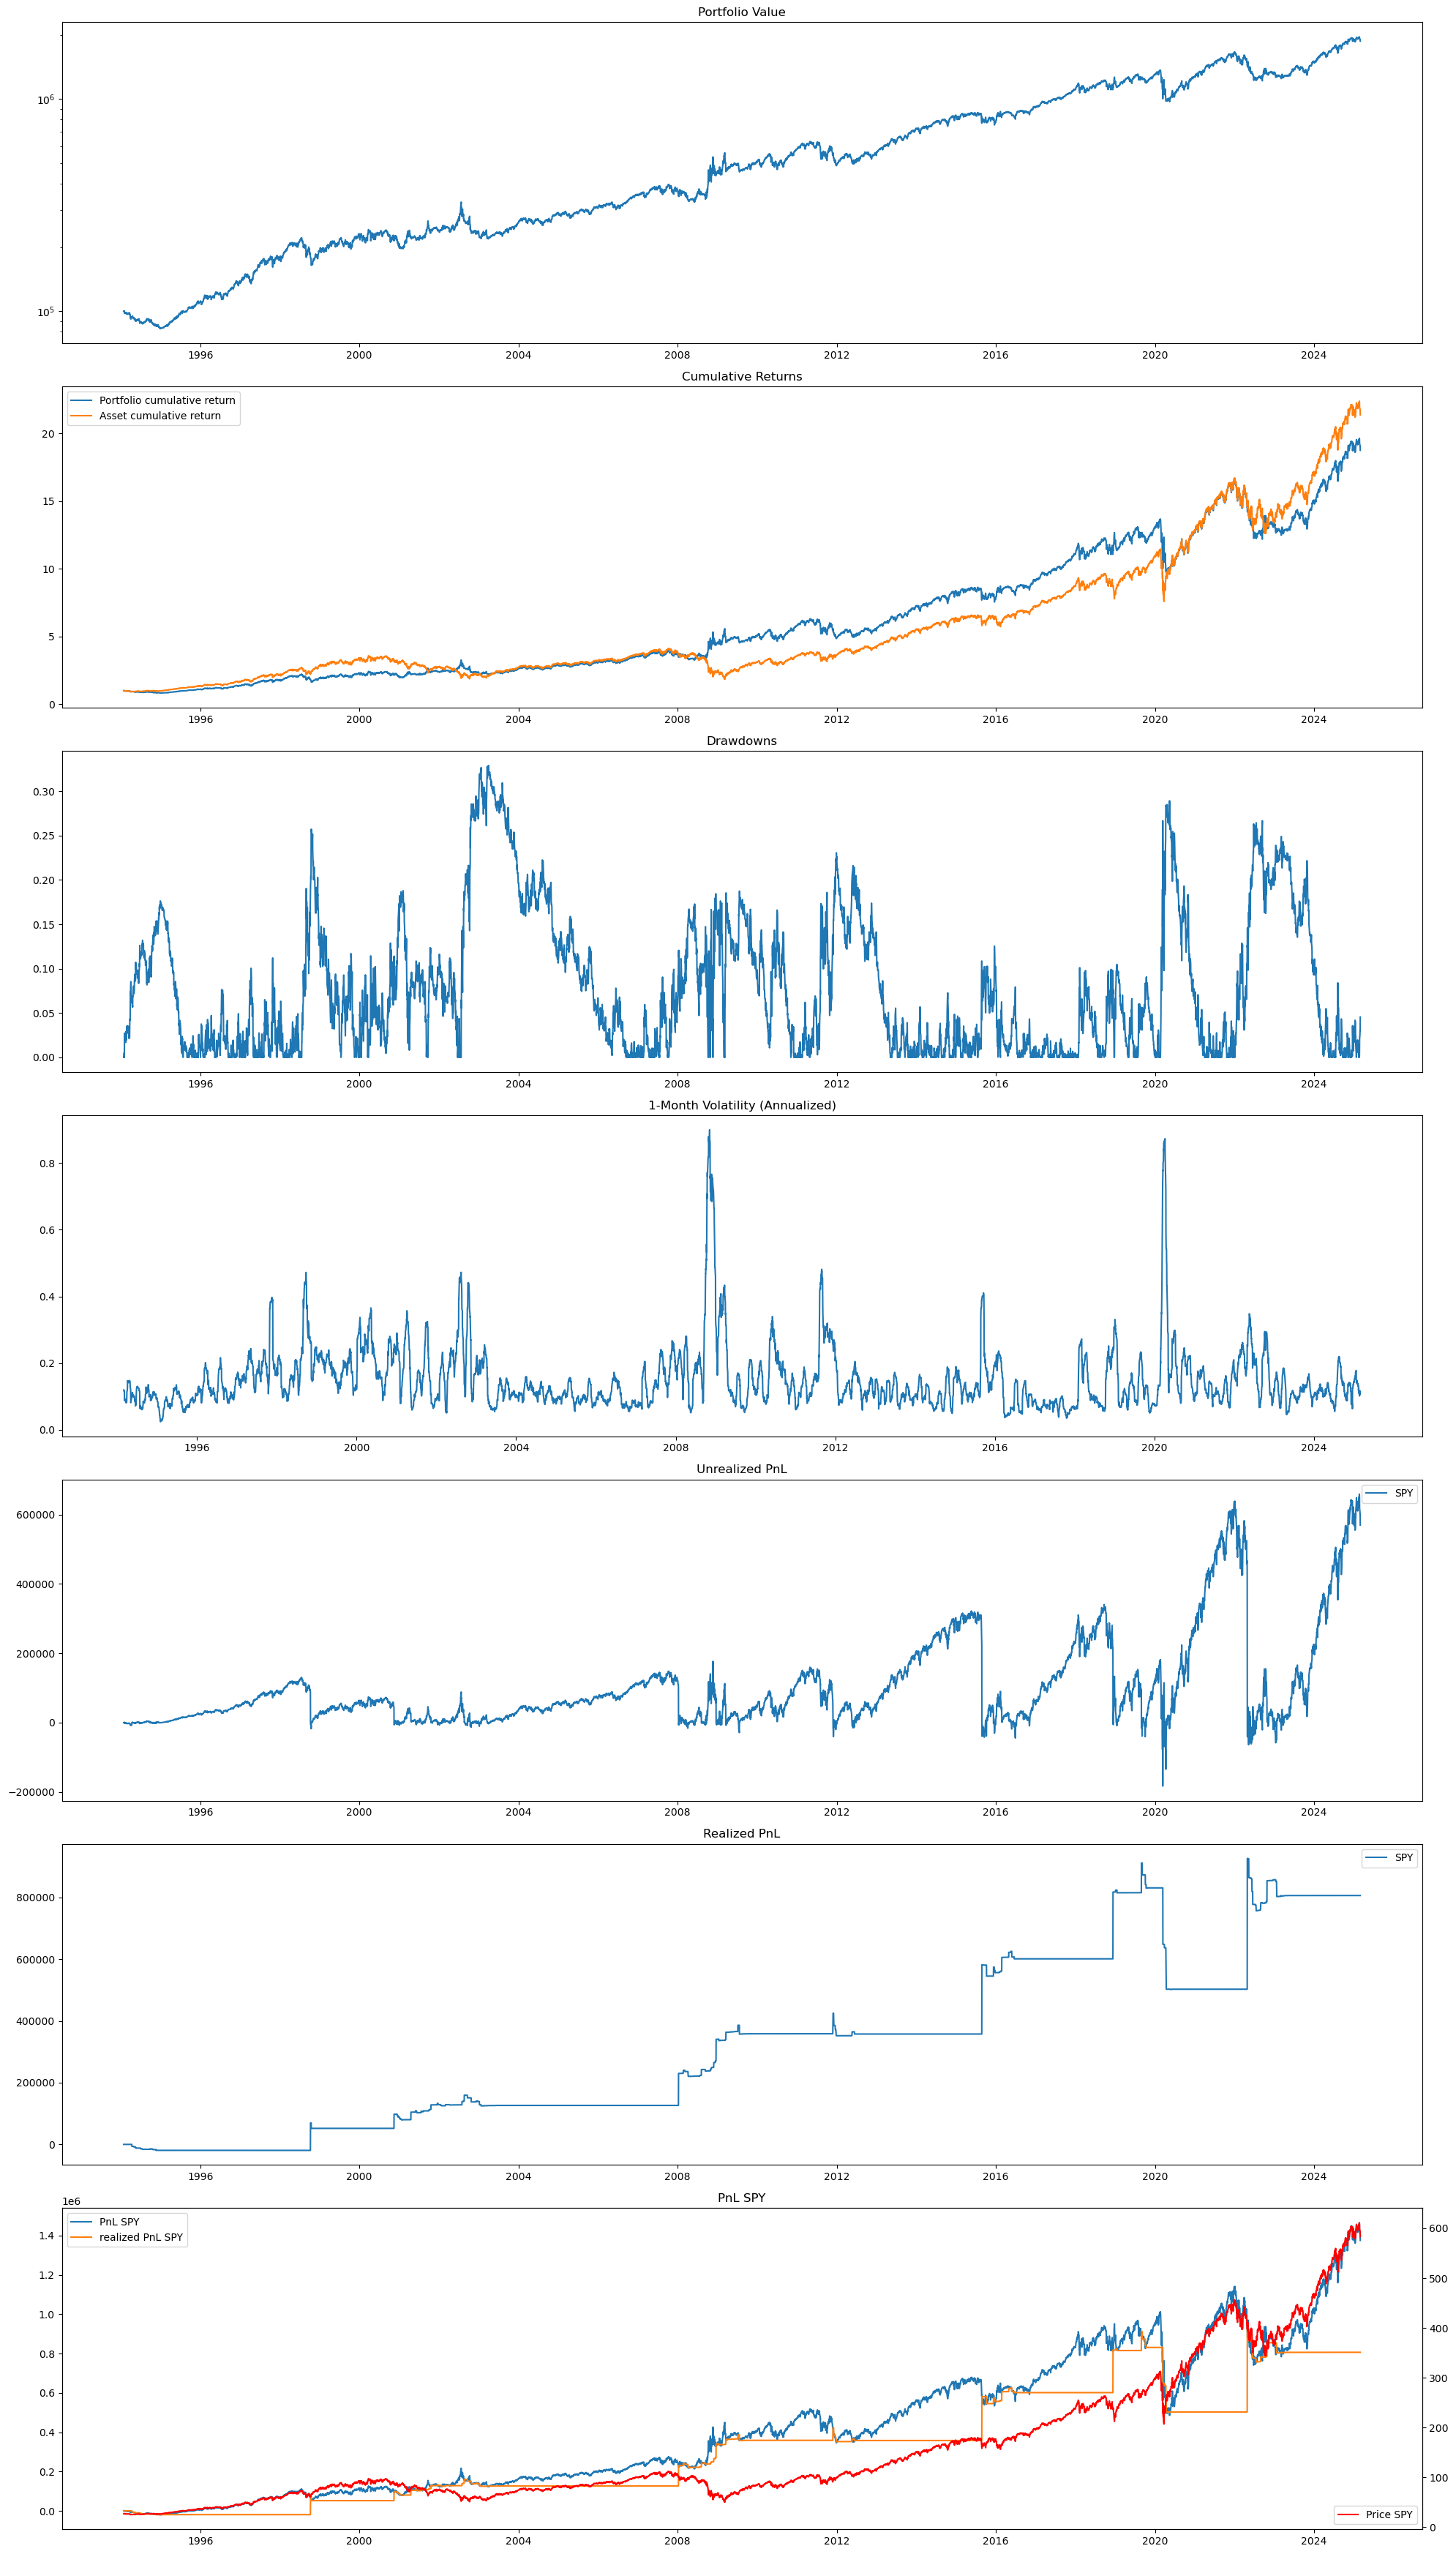

In [12]:
# opt_correction_weights = {
#     21: study.best_params['correction_weights_21'],
#     252: study.best_params['correction_weights_252'],
# }
# opt_rebound_weights = {
#     21: study.best_params['rebound_weights_21'],
#     252: study.best_params['rebound_weights_252'],
# }
opt_correction_weights = {
    21: 0,
    252: 1,
}
opt_rebound_weights = {
    21: 0.7,
    252: 0.3,
}

s = sum(opt_correction_weights.values())
opt_correction_weights = {key: value / s for key, value in opt_correction_weights.items()}
s = sum(opt_rebound_weights.values())
opt_rebound_weights = {key: value / s for key, value in opt_rebound_weights.items()}

print('correction', opt_correction_weights)
print('rebound', opt_rebound_weights)

# Initialize backtester
btr = BackTester({'SPY': df_data})
# Add strategy
btr.add_strategy(
    TrendSplitTrendStrategy, 
    tickers=['SPY'], 
    price_data={'SPY': df_data}, 
    rebalance_period=5,
    correction_weights=opt_correction_weights,
    rebound_weights=opt_rebound_weights)
results = btr.backtest()
print([f'{key}: {results[key]}' for key in results if key != 'returns'])
btr.plot_results()

### Comparison

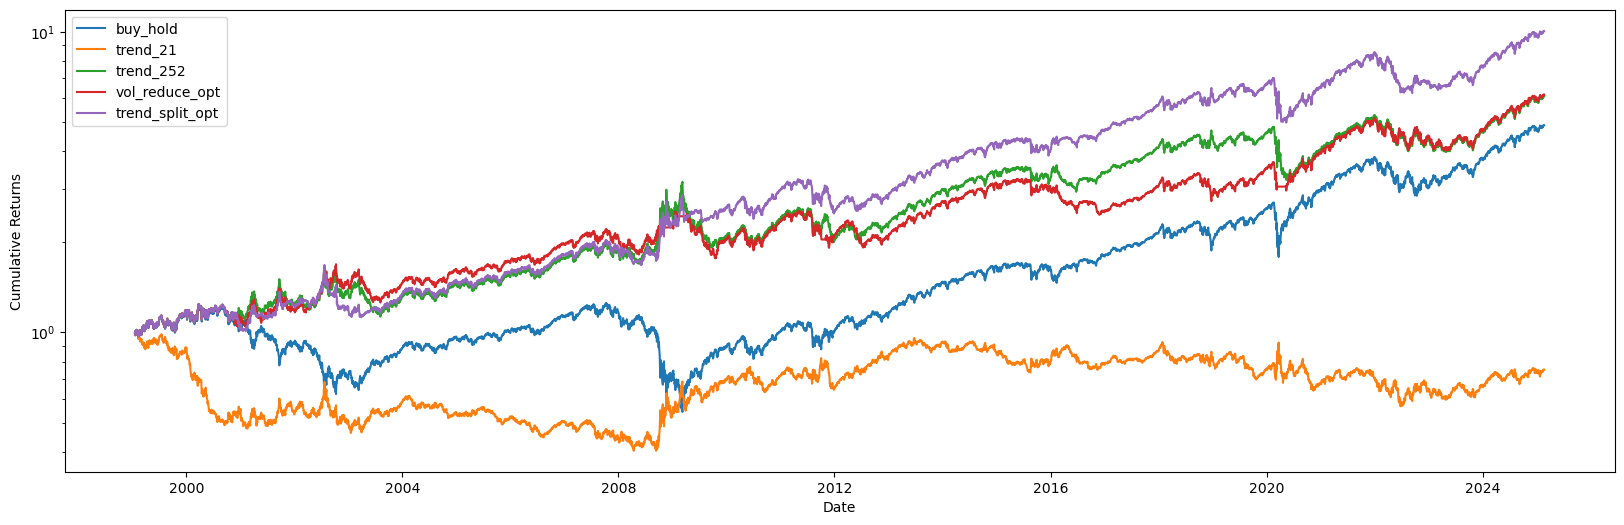

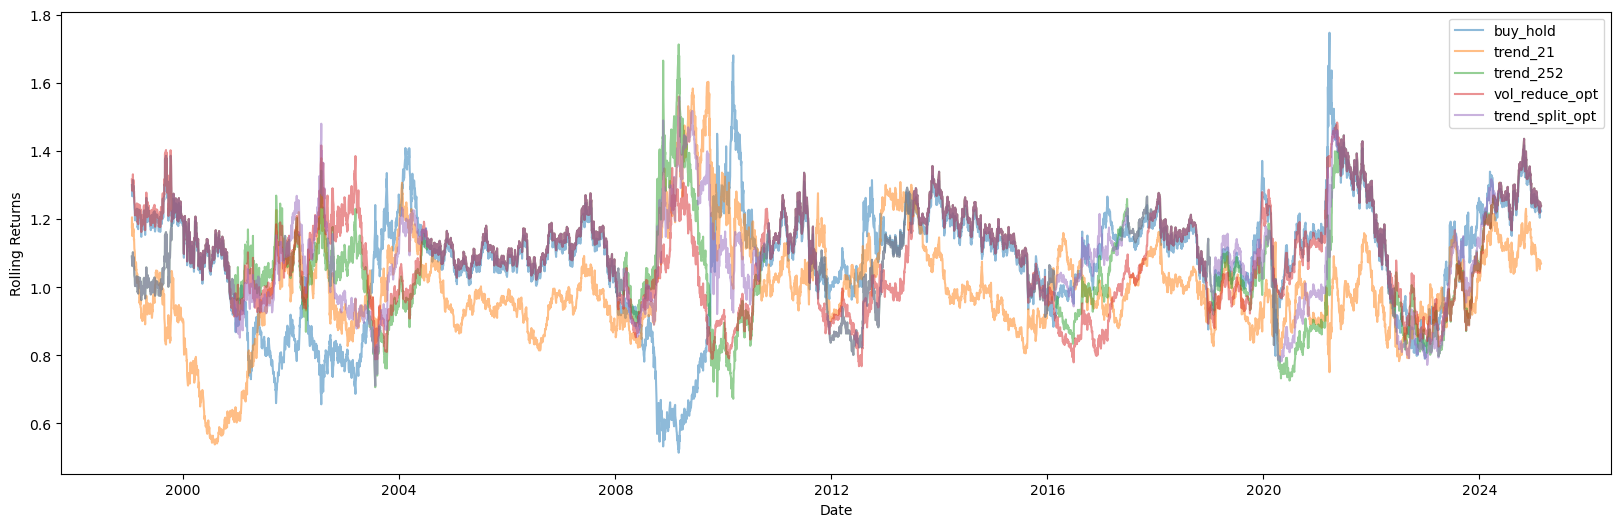

buy_hold
CAGR:           6.27%
Volatility:     19.34%
Sharpe Ratio:   0.32
--------------------------------------------
trend_21
CAGR:           -1.09%
Volatility:     18.98%
Sharpe Ratio:   -0.06
--------------------------------------------
trend_252
CAGR:           7.18%
Volatility:     19.25%
Sharpe Ratio:   0.37
--------------------------------------------
vol_reduce_opt
CAGR:           7.23%
Volatility:     16.73%
Sharpe Ratio:   0.43
--------------------------------------------
trend_split_opt
CAGR:           9.25%
Volatility:     18.22%
Sharpe Ratio:   0.51
--------------------------------------------


In [81]:
compare_returns(df_returns=results['returns'], col_name="trend_split_opt", plot=True)

# END

In [65]:
assert False

AssertionError: 

### Dependent variables
- forward mean return (21-days)
- forward vol (21-days)
- r_2 of linear regression of forward close prices

In [ ]:
def calc_forward_returns(df, period=21):
    """
    Calculate forward returns given dataframe with close prices and period
    """
    df = df.copy()
    df['temp_returns'] = df['close'].rolling(period).apply(lambda x: (x[-1] - x[0]) / x[0])
    df['temp_forward_returns'] = df['temp_returns'].shift(-period)
    return df['temp_forward_returns'].to_list()

def calc_binary_forward_returns(df, period=21):
    arr = calc_forward_returns(df, period)
    output_arr = []
    for i in arr:
        if i >= 0:
            output_arr.append(1)
        elif i < 0:
            output_arr.append(-1)
        else:
            output_arr.append(np.nan)
    return output_arr


def calc_forward_vol(df, period=21):
    """
    Calculate forward volatility given dataframe with close prices and period
    """
    df = df.copy()
    df['temp_ret'] = df['close'].pct_change()
    df['temp_vol'] = df['temp_ret'].rolling(period).apply(lambda x: np.std(x))
    df['temp_vol'] = df['temp_vol'].shift(-period)
    return df['temp_vol'].to_list()





df_data = df_raw.copy()
df_data['forward_returns'] = calc_forward_returns(df_data)
df_data['forward_binary_returns'] = calc_binary_forward_returns(df_data)
df_data['forward_vol'] = calc_forward_vol(df_data)
df_data

,open,high,low,close,adjclose,volume,dividends,stock_splits,capital_gains,forward_returns,forward_binary_returns,forward_vol
Date,,,,,,,,,,,,
1993-01-29,43.968750,43.968750,43.750000,43.937500,24.526073,1003200,0.0,0.0,0.0,0.015537,1.0,0.008034
1993-02-01,43.968750,44.250000,43.968750,44.250000,24.700506,480500,0.0,0.0,0.0,0.017618,1.0,0.007953
1993-02-02,44.218750,44.375000,44.125000,44.343750,24.752844,201300,0.0,0.0,0.0,0.001395,1.0,0.008067
1993-02-03,44.406250,44.843750,44.375000,44.812500,25.014509,529400,0.0,0.0,0.0,-0.005556,-1.0,0.007777
1993-02-04,44.968750,45.093750,44.468750,45.000000,25.119164,531500,0.0,0.0,0.0,0.017373,1.0,0.009096
...,...,...,...,...,...,...,...,...,...,...,...,...
2025-03-17,562.789978,569.710022,562.349976,567.150024,567.150024,49008700,0.0,0.0,0.0,NaN,NaN,NaN
2025-03-18,564.799988,565.020020,559.059998,561.020020,561.020020,66041400,0.0,0.0,0.0,NaN,NaN,NaN
2025-03-19,562.830017,570.950012,561.630005,567.130005,567.130005,66556000,0.0,0.0,0.0,NaN,NaN,NaN


#### Histograms

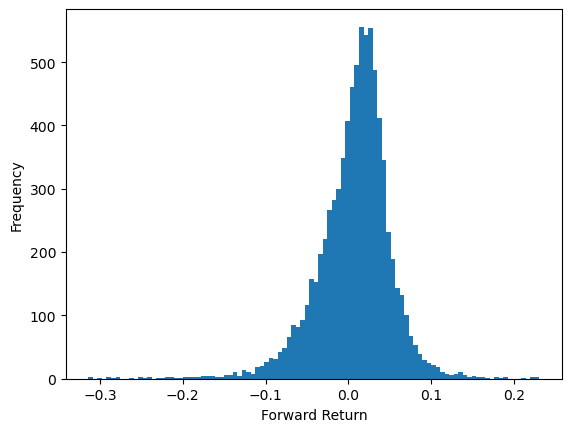

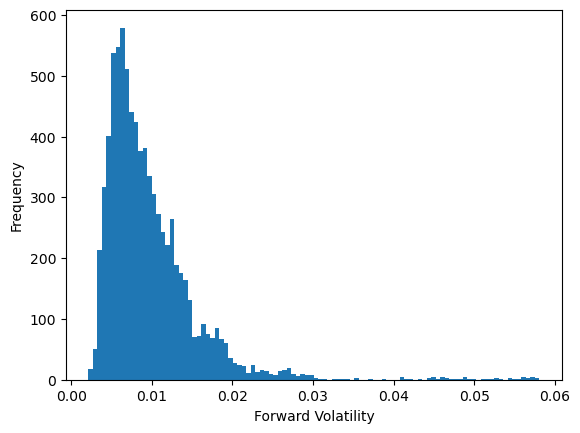

In [ ]:
# Forward returns
plt.hist(df_data['forward_returns'], bins=100)
plt.xlabel('Forward Return')
plt.ylabel('Frequency')
plt.show()

# Forward Volatility
plt.hist(df_data['forward_vol'], bins=100)
plt.xlabel('Forward Volatility')
plt.ylabel('Frequency')
plt.show()

### Independent Variables

In [ ]:
def calc_returns(df, period):
    df = df.copy()
    df['ret'] = df['close'].rolling(period).apply(lambda x: (x[-1] - x[0]) / x[0])
    return df['ret'].to_list()

def calc_binary_returns(df, period):
    df = df.copy()
    arr = calc_returns(df, period)
    output_arr = []
    for i in arr:
        if i >= 0:
            output_arr.append(1)
        elif i < 0:
            output_arr.append(-1)
        else:
            output_arr.append(np.nan)
    return output_arr

def calc_MA_returns(df, period):
    df = df.copy()
    df['temp_MA'] = df['close'].rolling(period).mean()
    df['ret_MA'] = df['close'] - df['temp_MA']  
    return df['ret_MA'].to_list()

def calc_binary_MA_returns(df, period):
    df = df.copy()
    arr = calc_MA_returns(df, period)
    output_arr = []
    for i in arr:
        if i >= 0:
            output_arr.append(1)
        elif i < 0:
            output_arr.append(-1)
        else:
            output_arr.append(np.nan)
    return output_arr

def calc_breakout(df, breakout_period=252, rebalance_period=21):
    """
    Calculate breakout signals based on max/min comparisons between two rolling windows.
    
    Args:
        df: DataFrame containing price data
        'close': Name of the price column
        breakout_period: Shorter window for potential breakout detection
        rebalance_period: Longer window for reference levels
    
    Returns:
        DataFrame with 'breakout' column containing signals (-1, 0, 1)
    """
    df = df.copy()
    # Convert periods to integers for safety
    breakout_period = int(breakout_period)
    rebalance_period = int(rebalance_period)
    
    # Calculate rolling max/min for both periods
    df['breakout_max'] = df['close'].rolling(breakout_period).max()
    df['rebalance_max'] = df['close'].rolling(rebalance_period).max()
    df['breakout_min'] = df['close'].rolling(breakout_period).min()
    df['rebalance_min'] = df['close'].rolling(rebalance_period).min()
    
    # Calculate breakout signals
    df['breakout_signal'] = np.where(
        df['breakout_max'] == df['rebalance_max'], 1,
        np.where(
            df['breakout_min'] == df['rebalance_min'], -1, 0
        )
    )
        
    return df['breakout_signal'].to_list()

def calc_atr(df, period=14, high_col='high', low_col='low', close_col='close'):
    """
    Calculate the Average True Range (ATR) for a given DataFrame.

    Args:
        df: DataFrame containing price data
        period: ATR calculation period (default: 14)
        high_col: Name of the high price column
        low_col: Name of the low price column
        close_col: Name of the close price column

    Returns:
        DataFrame with 'TR' (True Range) and 'ATR' columns added
    """
    df = df.copy()
    # Calculate the previous close
    df['prev_close'] = df[close_col].shift(1)
    
    # Compute the three potential true ranges
    tr1 = df[high_col] - df[low_col]
    tr2 = (df[high_col] - df['prev_close']).abs()
    tr3 = (df[low_col] - df['prev_close']).abs()
    
    # Element-wise maximum of the three values gives the True Range (TR)
    df['TR'] = np.maximum(np.maximum(tr1, tr2), tr3)
    
    # Calculate the ATR using an exponential moving average (EMA) of TR
    df['ATR'] = df['TR'].ewm(span=period, adjust=False).mean()
    df['ATR'] = df['ATR'] / df['prev_close']
    
    return df['ATR'].to_list()

def calc_vix(df, df_vix):
    df = df.copy()
    df['vix'] = df_vix['close']
    return df


def calc_rel_volume(df, ref_period=50):
    df = df.copy()
    df['rel_volume'] = df['volume'] / df['volume'].rolling(ref_period).mean()
    return df['rel_volume'].to_list()


def calc_r2(df, period=21):
    """
    Calculate R2 given dataframe with close prices and period
    """
    df = df.copy()
    r2_arr = []
    for i in range(df.shape[0]):
        if i < period:
           r2_arr.append(np.nan)
        else:
            # r2 is the R2 error term for a linear regression of log prices
            # We fit a linear regression of the log prices over unit time and then calculate the R2 with sklearn r2_score
            # R2 denotes how closely the log prices follow a linear trend
            close_prices_arr = df[i - period: i]['close'].to_numpy()
            assert close_prices_arr.shape[0] == period
            log_prices_arr = np.log(close_prices_arr)
            model = LinearRegression()
            model.fit(np.arange(period).reshape(-1, 1), log_prices_arr)
            r2 = r2_score(log_prices_arr, model.predict(np.arange(period).reshape(-1, 1)))
            r2_arr.append(r2)
    
    return r2_arr




df_vix = pd.read_pickle(f'./data/raw/price/^VIX_{current_date}.pkl')
df_data = calc_vix(df_data, df_vix)

time_periods = [5, 10, 14, 21, 50, 100, 200, 252, 500]
for period in tqdm(time_periods):
    df_data[f'ret_MA_{period}'] = calc_MA_returns(df_data, period)
    df_data[f'ret_{period}'] = calc_returns(df_data, period)


for period in tqdm(time_periods):
    df_data[f'ret_MA_binary_{period}'] = calc_binary_MA_returns(df_data, period)
    df_data[f'ret_binary_{period}'] = calc_binary_returns(df_data, period)
    
for period in tqdm(time_periods):
    df_data[f'rel_volume_{period}'] = calc_rel_volume(df_data, period)
    df_data[f'ATR_{period}'] = calc_atr(df_data, period)
    if period >= 21:
        df_data[f'breakout_{period}'] = calc_breakout(df_data, period, 21)
        df_data[f'r2_{period}'] = calc_r2(df_data, period)

df_data.dropna(inplace=True)
df_data



  0%|          | 0/9 [00:00<?, ?it/s]

  0%|          | 0/9 [00:00<?, ?it/s]

  0%|          | 0/9 [00:00<?, ?it/s]

,open,high,low,close,adjclose,volume,dividends,stock_splits,capital_gains,forward_returns,...,breakout_200,r2_200,rel_volume_252,ATR_252,breakout_252,r2_252,rel_volume_500,ATR_500,breakout_500,r2_500
Date,,,,,,,,,,,,,,,,,,,,,
1995-01-23,46.234375,46.687500,46.203125,46.687500,27.428968,53700,0.0,0.0,0.0,0.043783,...,0,0.247089,0.136917,0.008222,0,0.000407,0.173687,0.007898,0,0.208639
1995-01-24,46.671875,46.750000,46.640625,46.750000,27.465700,32400,0.0,0.0,0.0,0.042667,...,0,0.246313,0.082896,0.008151,0,0.000040,0.105099,0.007852,0,0.206611
1995-01-25,46.515625,47.046875,46.515625,46.875000,27.539104,15700,0.0,0.0,0.0,0.044289,...,0,0.243568,0.040289,0.008166,0,0.000045,0.050989,0.007855,0,0.205265
1995-01-26,46.843750,46.984375,46.750000,46.921875,27.566647,9800,0.0,0.0,0.0,0.031841,...,0,0.242759,0.025183,0.008119,0,0.000430,0.031935,0.007823,0,0.204365
1995-01-27,47.234375,47.234375,46.921875,47.109375,27.676819,91200,0.0,0.0,0.0,0.044970,...,0,0.241720,0.234966,0.008100,0,0.001303,0.298049,0.007811,0,0.204568
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-02-13,604.479980,609.940002,603.200012,609.729980,609.729980,40921300,0.0,0.0,0.0,-0.069788,...,1,0.872360,0.760733,0.010037,1,0.914035,0.604663,0.009686,1,0.957518
2025-02-14,609.940002,610.989990,609.070007,609.700012,609.700012,26910400,0.0,0.0,0.0,-0.082536,...,1,0.872076,0.503469,0.009878,1,0.913974,0.398217,0.009560,1,0.957910
2025-02-18,610.880005,611.489990,608.380005,611.489990,611.489990,26749000,0.0,0.0,0.0,-0.074723,...,1,0.871674,0.502002,0.009841,1,0.913760,0.396562,0.009542,1,0.958120


In [ ]:
import pandas as pd

def calculate_supertrend(df, period=14, multiplier=3):
    """
    Calculate SuperTrend indicator
    Args:
        df: DataFrame with columns ['high', 'low', 'close']
        period: ATR period (default: 14)
        multiplier: ATR multiplier (default: 3)
    Returns:
        DataFrame with 'supertrend', 'direction', 'upper_band', 'lower_band' columns
    """
    df = df.copy()
    
    # Calculate HL2
    df['hl2'] = (df['high'] + df['low']) / 2
    
    # Calculate ATR
    df['tr'] = pd.concat([
        df['high'] - df['low'],
        abs(df['high'] - df['close'].shift()),
        abs(df['low'] - df['close'].shift())
    ], axis=1).max(axis=1)
    df['atr'] = df['tr'].rolling(period).mean()
    
    # Calculate basic bands
    df['basic_upper'] = df['hl2'] + multiplier * df['atr']
    df['basic_lower'] = df['hl2'] - multiplier * df['atr']
    
    # Initialize final bands
    df['upper_band'] = df['basic_upper']
    df['lower_band'] = df['basic_lower']
    df['supertrend'] = 0.0
    df['direction'] = 'down'  # Initial direction
    
    for i in range(1, len(df)):
        # Update upper band
        if (df['basic_upper'].iloc[i] < df['upper_band'].iloc[i-1]) or \
           (df['close'].iloc[i-1] > df['upper_band'].iloc[i-1]):
            df['upper_band'].iat[i] = df['basic_upper'].iloc[i]
        else:
            df['upper_band'].iat[i] = df['upper_band'].iloc[i-1]
            
        # Update lower band
        if (df['basic_lower'].iloc[i] > df['lower_band'].iloc[i-1]) or \
           (df['close'].iloc[i-1] < df['lower_band'].iloc[i-1]):
            df['lower_band'].iat[i] = df['basic_lower'].iloc[i]
        else:
            df['lower_band'].iat[i] = df['lower_band'].iloc[i-1]
            
        # Determine trend direction
        if df['close'].iloc[i] > df['upper_band'].iloc[i]:
            df['direction'].iat[i] = 'up'
        elif df['close'].iloc[i] < df['lower_band'].iloc[i]:
            df['direction'].iat[i] = 'down'
        else:
            df['direction'].iat[i] = df['direction'].iloc[i-1]
            
        # Set SuperTrend value
        df['supertrend'].iat[i] = (
            df['lower_band'].iloc[i] if df['direction'].iloc[i] == 'up'
            else df['upper_band'].iloc[i]
        )
    
    # Cleanup intermediate columns
    df.drop(['hl2', 'tr', 'basic_upper', 'basic_lower'], axis=1, inplace=True)
    return df

# Usage example:
# df = calculate_supertrend(df, period=14, multiplier=3)

### Train-Test Split

In [ ]:
def get_train_test_split(df, n):
    df = df.copy()
    
    tscv = TimeSeriesSplit(n_splits=n)

    data = []
    # Perform the time series split
    for train_index, test_index in tscv.split(df):
        train_data = df.iloc[train_index]
        test_data = df.iloc[test_index]
        
        data.append({
            'train': train_data,
            'test': test_data,
        })
    
    return data

# train_cols = [f for f in df_data.columns if f not in ['open', 'high', 'low', 'close', 'adjclose', 'volume', 'dividends', 'stock_splits', 'capital_gains', 'forward_returns', 'forward_vol']]
train_cols = ['vix', 
            #   'ret_MA_5', 'ret_5', 'ret_MA_10', 'ret_10', 'ret_MA_14', 'ret_14', 'ret_MA_21', 'ret_21', 'ret_MA_50', 'ret_50', 'ret_MA_100', 'ret_100', 'ret_MA_200', 'ret_200', 'ret_MA_252', 'ret_252', 'ret_MA_500', 'ret_500', 
              'ret_MA_binary_5', 'ret_binary_5', 'ret_MA_binary_10', 'ret_binary_10', 'ret_MA_binary_14', 'ret_binary_14', 'ret_MA_binary_21', 'ret_binary_21', 'ret_MA_binary_50', 'ret_binary_50', 'ret_MA_binary_100', 'ret_binary_100', 'ret_MA_binary_200', 'ret_binary_200', 'ret_MA_binary_252', 'ret_binary_252', 'ret_MA_binary_500', 'ret_binary_500', 
              'rel_volume_5', 'ATR_5', 'rel_volume_10', 'ATR_10', 'rel_volume_14', 'ATR_14', 'rel_volume_21', 'ATR_21', 'breakout_21', 'r2_21', 'rel_volume_50', 'ATR_50', 'breakout_50', 'r2_50', 'rel_volume_100', 'ATR_100', 'breakout_100', 'r2_100', 'rel_volume_200', 'ATR_200', 'breakout_200', 'r2_200', 'rel_volume_252', 'ATR_252', 'breakout_252', 'r2_252', 'rel_volume_500', 'ATR_500', 'breakout_500', 'r2_500']

# test_cols = ['forward_binary_returns']
test_cols = ['forward_returns']

print(f'train_cols: {train_cols}')
print(f'test_cols: {test_cols}')

train_cols: ['vix', 'ret_MA_binary_5', 'ret_binary_5', 'ret_MA_binary_10', 'ret_binary_10', 'ret_MA_binary_14', 'ret_binary_14', 'ret_MA_binary_21', 'ret_binary_21', 'ret_MA_binary_50', 'ret_binary_50', 'ret_MA_binary_100', 'ret_binary_100', 'ret_MA_binary_200', 'ret_binary_200', 'ret_MA_binary_252', 'ret_binary_252', 'ret_MA_binary_500', 'ret_binary_500', 'rel_volume_5', 'ATR_5', 'rel_volume_10', 'ATR_10', 'rel_volume_14', 'ATR_14', 'rel_volume_21', 'ATR_21', 'breakout_21', 'r2_21', 'rel_volume_50', 'ATR_50', 'breakout_50', 'r2_50', 'rel_volume_100', 'ATR_100', 'breakout_100', 'r2_100', 'rel_volume_200', 'ATR_200', 'breakout_200', 'r2_200', 'rel_volume_252', 'ATR_252', 'breakout_252', 'r2_252', 'rel_volume_500', 'ATR_500', 'breakout_500', 'r2_500']
test_cols: ['forward_returns']


## Prediction with binary variables

In [ ]:
def continuous_to_binary(arr, parameter, mode='percentile'):
    """
    Convert a continuous variable to a binary variable based on the specified mode and parameter.

    Parameters:
    arr (numpy array): The input array of continuous values.
    parameter (float): The threshold or percentile value depending on the mode.
    mode (str): The mode of operation. Can be 'percentile' or 'limit'.

    Returns:
    numpy array: A binary array where values are 0 or 1 based on the specified mode.
    """
    if mode == 'percentile':
        # Calculate the specified percentile of the array
        threshold = np.percentile(arr, parameter)
        binary_arr = np.where(arr > threshold, 1, 0)
    elif mode == 'limit':
        # Use the parameter as the threshold
        binary_arr = np.where(arr > parameter, 1, 0)
    else:
        raise ValueError("Invalid mode. Mode must be 'percentile' or 'limit'.")

    return binary_arr

# convert to binary
train_cols = []
for col in ['vix', 'rel_volume_5', 'ATR_5', 'rel_volume_10', 'ATR_10', 'rel_volume_14', 'ATR_14', 'rel_volume_21', 'ATR_21', 'r2_21', 'rel_volume_50', 'ATR_50', 'r2_50', 'rel_volume_100', 'ATR_100',  'r2_100', 'rel_volume_200', 'ATR_200',  'r2_200', 'rel_volume_252', 'ATR_252', 'r2_252', 'rel_volume_500', 'ATR_500', 'r2_500']:
    df_data[col + '_binary'] = continuous_to_binary(df_data[col], 50, mode='percentile')
    train_cols.append(col + '_binary')

train_cols += ['ret_MA_binary_5', 'ret_binary_5', 'ret_MA_binary_10', 'ret_binary_10', 'ret_MA_binary_14', 'ret_binary_14', 'ret_MA_binary_21', 'ret_binary_21', 'ret_MA_binary_50', 'ret_binary_50', 'ret_MA_binary_100', 'ret_binary_100', 'ret_MA_binary_200', 'ret_binary_200', 'ret_MA_binary_252', 'ret_binary_252', 'ret_MA_binary_500', 'ret_binary_500']

df_data[train_cols]

,vix_binary,rel_volume_5_binary,ATR_5_binary,rel_volume_10_binary,ATR_10_binary,rel_volume_14_binary,ATR_14_binary,rel_volume_21_binary,ATR_21_binary,r2_21_binary,...,ret_MA_binary_50,ret_binary_50,ret_MA_binary_100,ret_binary_100,ret_MA_binary_200,ret_binary_200,ret_MA_binary_252,ret_binary_252,ret_MA_binary_500,ret_binary_500
Date,,,,,,,,,,,,,,,,,,,,,
1995-01-23,0,0,0,0,0,0,0,0,0,1,...,1.0,1.0,1.0,-1.0,1.0,1.0,1.0,-1.0,1.0,1.0
1995-01-24,0,0,0,0,0,0,0,0,0,1,...,1.0,1.0,1.0,-1.0,1.0,1.0,1.0,-1.0,1.0,1.0
1995-01-25,0,0,0,0,0,0,0,0,0,1,...,1.0,1.0,1.0,-1.0,1.0,1.0,1.0,-1.0,1.0,1.0
1995-01-26,0,0,0,0,0,0,0,0,0,1,...,1.0,1.0,1.0,-1.0,1.0,1.0,1.0,-1.0,1.0,1.0
1995-01-27,0,1,0,1,0,0,0,0,0,1,...,1.0,1.0,1.0,-1.0,1.0,1.0,1.0,-1.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-02-13,0,1,0,1,0,0,0,0,0,0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
2025-02-14,0,0,0,0,0,0,0,0,0,0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
2025-02-18,0,0,0,0,0,0,0,0,0,0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


In [ ]:
test_cols

['forward_returns']

### Prediction with Linear Regression

  0%|          | 0/5 [00:00<?, ?it/s]

RMSE: 0.006699535006920798


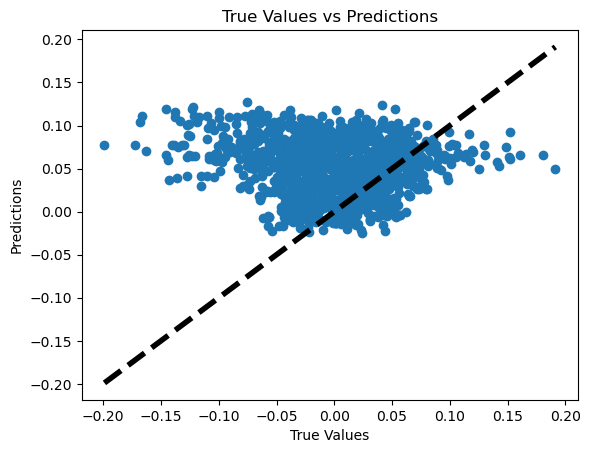

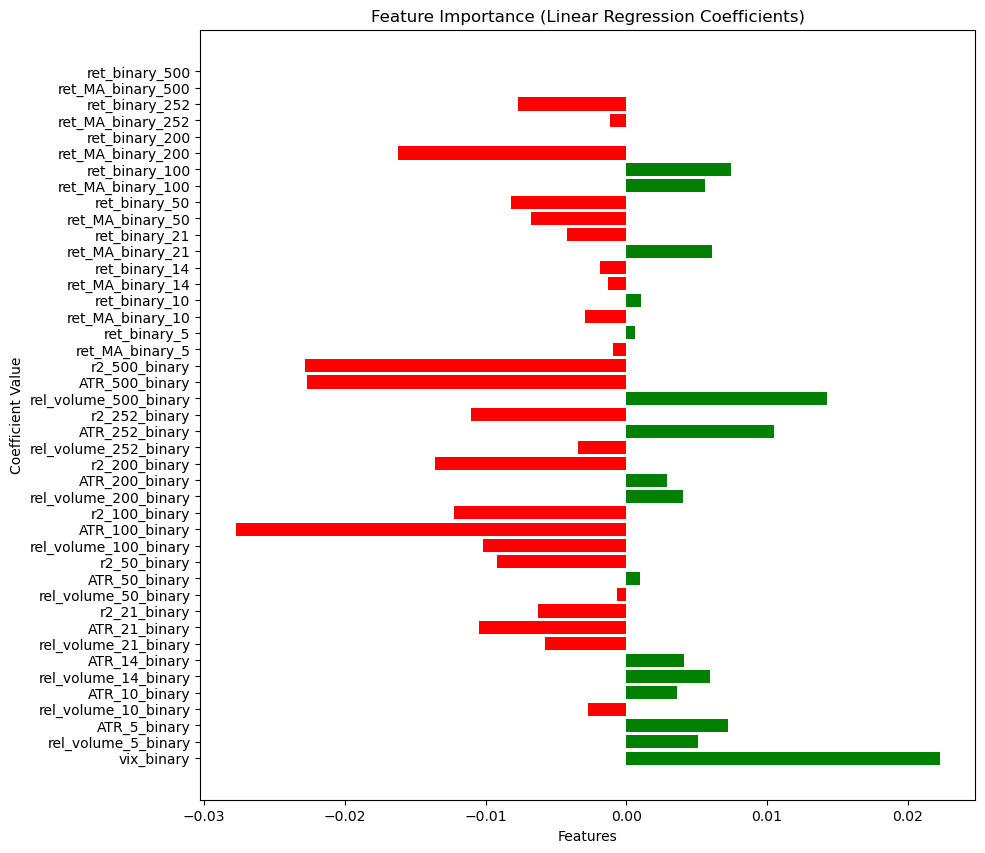

[ 2.23104677e-02  5.11734477e-03  7.22315181e-03 -2.68628281e-03
  3.60348966e-03  5.96736305e-03  4.11263575e-03 -5.79473251e-03
 -1.04789096e-02 -6.27195524e-03 -6.59267374e-04  9.66971004e-04
 -9.15979282e-03 -1.01938388e-02 -2.77747677e-02 -1.22592960e-02
  4.00915794e-03  2.89474977e-03 -1.36016028e-02 -3.46244309e-03
  1.05199265e-02 -1.10685408e-02  1.42897801e-02 -2.27157793e-02
 -2.28223384e-02 -9.20613086e-04  6.21146948e-04 -2.91154632e-03
  1.06599939e-03 -1.30341025e-03 -1.88891724e-03  6.11150225e-03
 -4.21173189e-03 -6.78511477e-03 -8.20486115e-03  5.58281902e-03
  7.45503828e-03 -1.62417826e-02 -1.28369537e-16 -1.16665819e-03
 -7.72769836e-03  0.00000000e+00  0.00000000e+00]
RMSE: 0.0032764916467681827


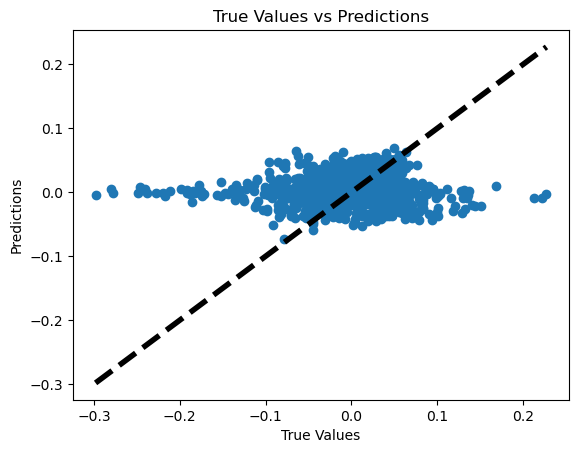

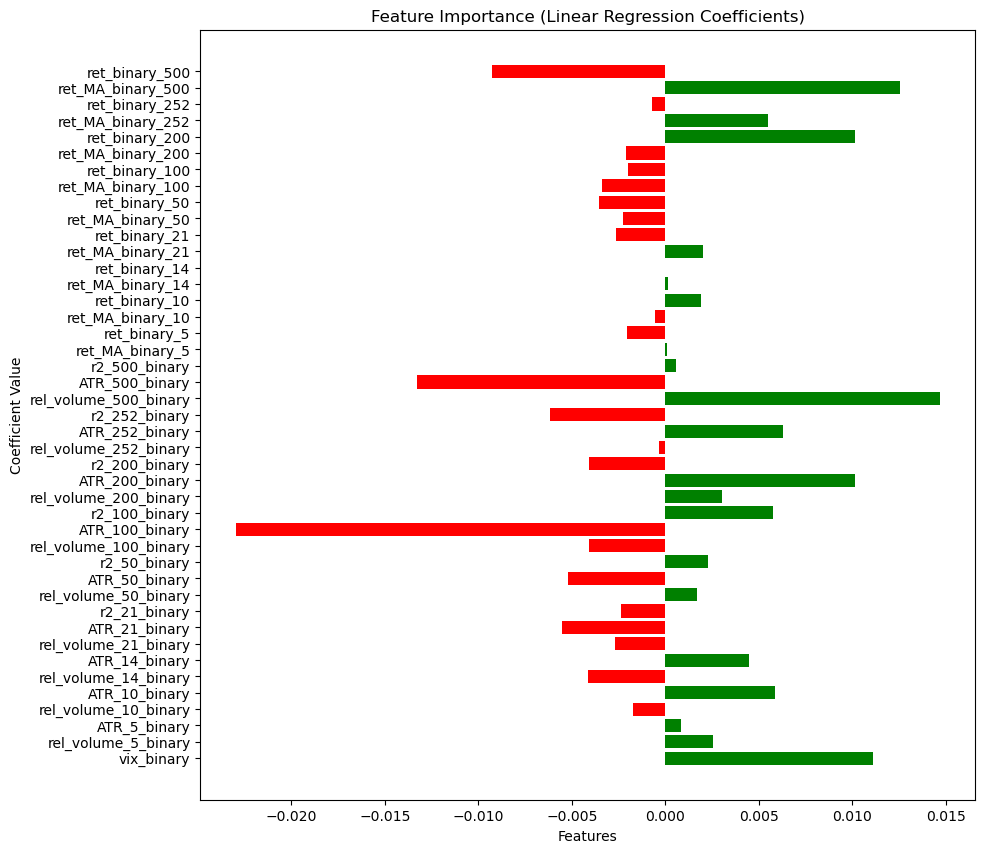

[ 1.10842327e-02  2.53907470e-03  8.31783491e-04 -1.76270179e-03
  5.84133300e-03 -4.11613617e-03  4.47157668e-03 -2.70192101e-03
 -5.54570628e-03 -2.38615712e-03  1.70142407e-03 -5.20920574e-03
  2.26860898e-03 -4.11323747e-03 -2.29935561e-02  5.73879815e-03
  3.04179598e-03  1.01602734e-02 -4.06856017e-03 -3.25644855e-04
  6.28955808e-03 -6.18558629e-03  1.46841526e-02 -1.33056065e-02
  5.71804836e-04  6.74057808e-05 -2.03900532e-03 -5.44835224e-04
  1.91126088e-03  1.16730530e-04 -1.23914307e-05  1.98086881e-03
 -2.61942104e-03 -2.29340931e-03 -3.57623766e-03 -3.38220774e-03
 -1.98037960e-03 -2.10976698e-03  1.01182691e-02  5.47451795e-03
 -7.40051169e-04  1.25171532e-02 -9.28063376e-03]
RMSE: 0.0017637340504061169


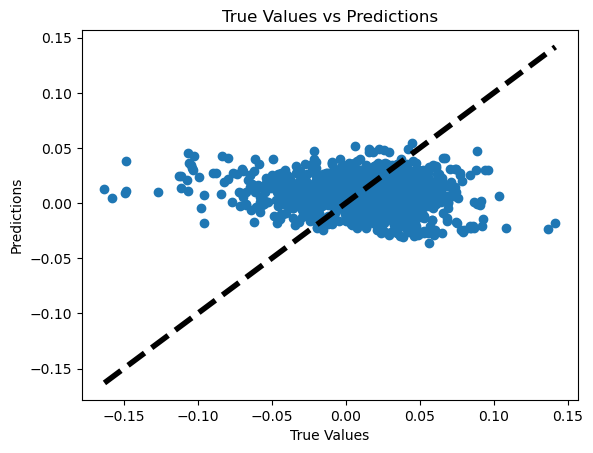

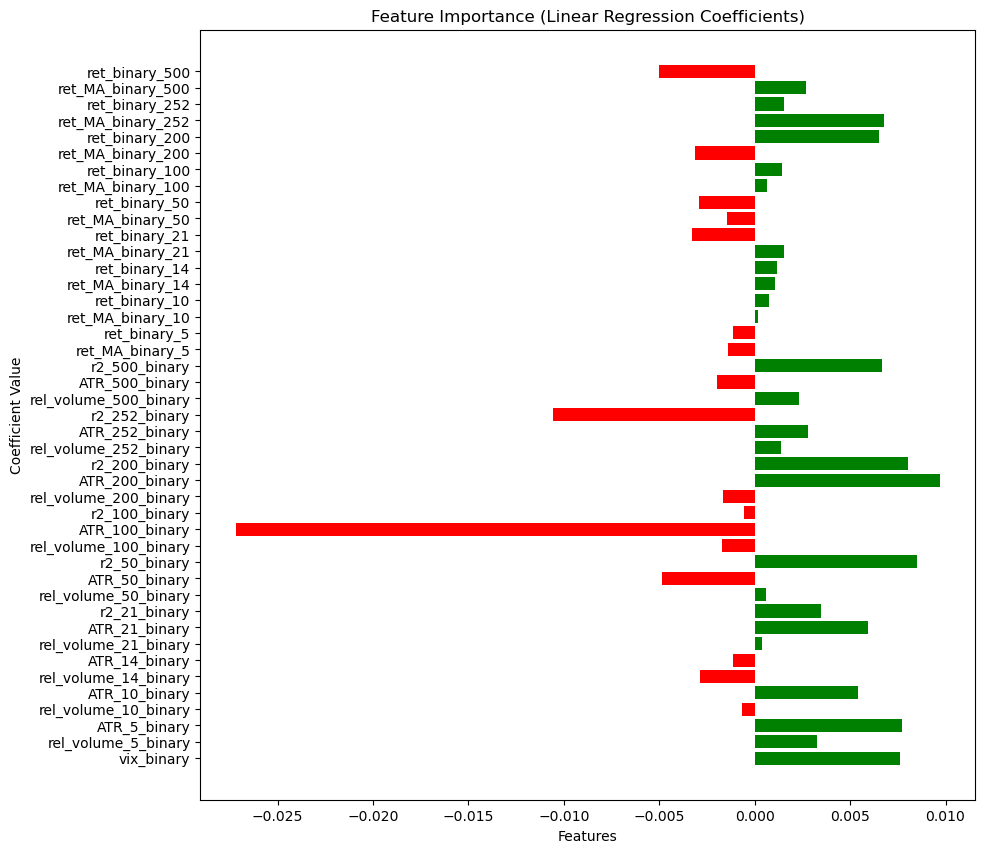

[ 0.00759282  0.0032686   0.00773439 -0.00064096  0.00542738 -0.00288777
 -0.00112824  0.00039317  0.00591772  0.00349515  0.00056801 -0.00483491
  0.00848685 -0.00173255 -0.02720572 -0.00053939 -0.00167965  0.00971397
  0.00802647  0.00139456  0.00281639 -0.01054948  0.0023118  -0.00196549
  0.00666838 -0.00141277 -0.0011108   0.00018707  0.00073684  0.00104211
  0.00117402  0.00155648 -0.00330837 -0.0014495  -0.00289661  0.00062812
  0.00145246 -0.00313152  0.00651084  0.00680104  0.00153726  0.00268327
 -0.00501598]
RMSE: 0.0014578461532562751


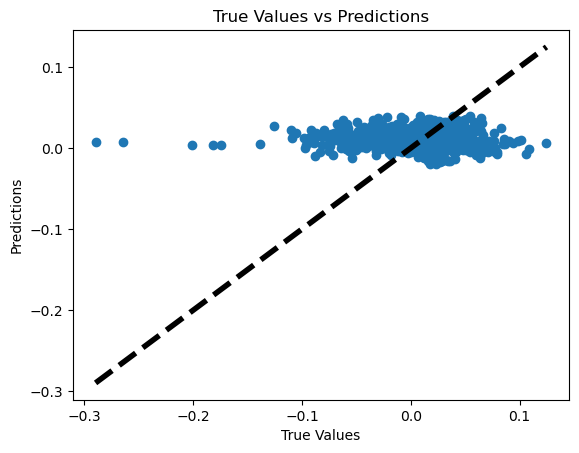

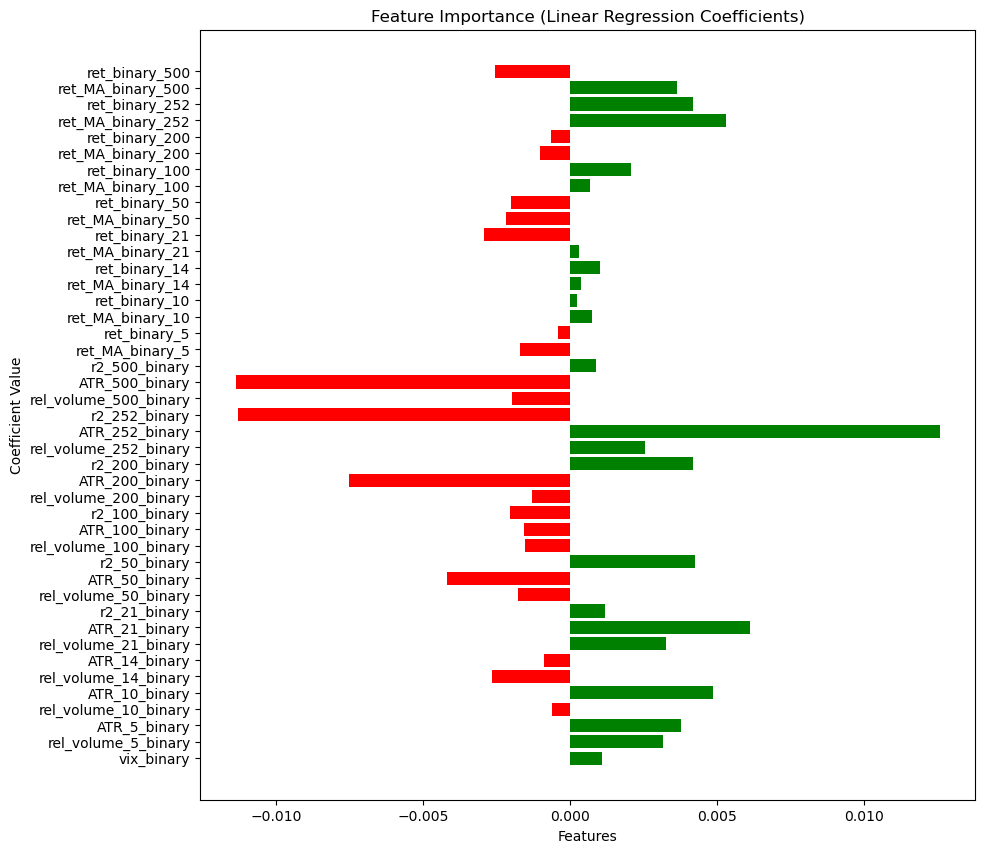

[ 0.00109541  0.00314736  0.0037586  -0.00060316  0.00485474 -0.00264926
 -0.0008789   0.0032549   0.00612386  0.0011772  -0.00177233 -0.00416926
  0.00425773 -0.00153106 -0.00157091 -0.00205557 -0.00131177 -0.00751501
  0.00418108  0.00255365  0.01256809 -0.01129556 -0.00198331 -0.01137108
  0.00088297 -0.00171829 -0.00039756  0.00073682  0.00023041  0.00035412
  0.00101747  0.00028895 -0.00294137 -0.00216728 -0.00199349  0.00066118
  0.00205257 -0.00101541 -0.00063689  0.00530577  0.00418038  0.00364598
 -0.0025459 ]
RMSE: 0.002665828589839049


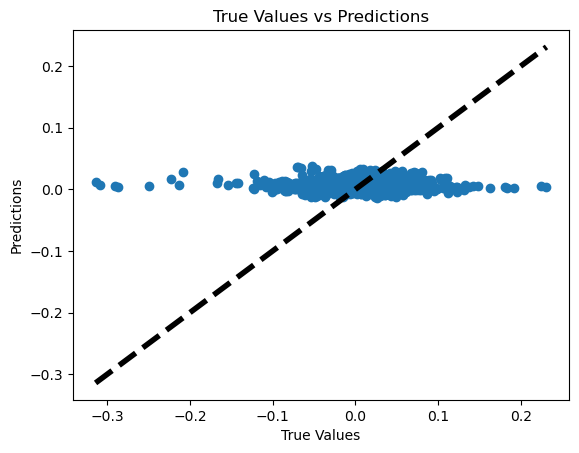

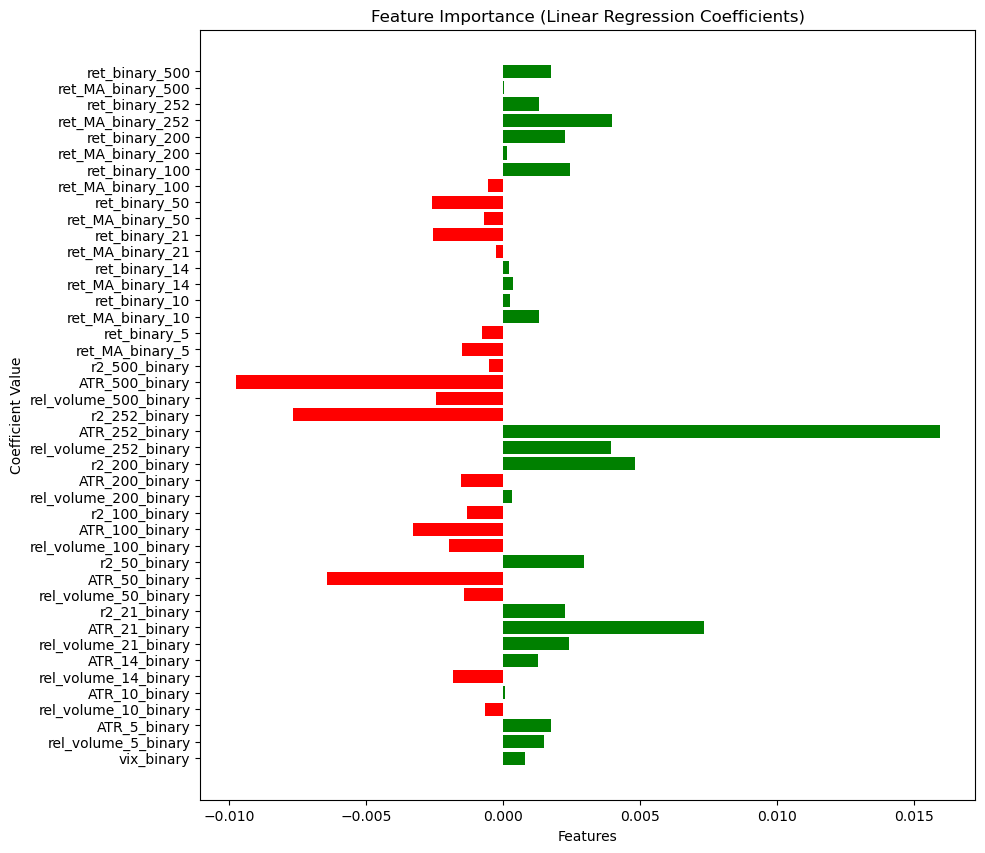

[ 8.06942123e-04  1.51519498e-03  1.76540164e-03 -6.54756928e-04
  7.31830651e-05 -1.83192710e-03  1.26837148e-03  2.42655762e-03
  7.34658088e-03  2.25156055e-03 -1.40761961e-03 -6.42175941e-03
  2.96684055e-03 -1.96049283e-03 -3.26450353e-03 -1.32388794e-03
  3.40628706e-04 -1.51605088e-03  4.83813375e-03  3.95667469e-03
  1.59657600e-02 -7.65318010e-03 -2.42764903e-03 -9.76269572e-03
 -4.88962761e-04 -1.48861416e-03 -7.60249675e-04  1.32785158e-03
  2.56241648e-04  3.84376642e-04  2.23753118e-04 -2.37206550e-04
 -2.55866183e-03 -7.01203309e-04 -2.57207140e-03 -5.59571538e-04
  2.45888795e-03  1.55347244e-04  2.26704919e-03  3.99060502e-03
  1.31916992e-03  3.09963832e-05  1.75815634e-03]


In [ ]:
data = get_train_test_split(df_data, 5)

for i in tqdm(range(len(data))):
    X_train = data[i]['train'][train_cols]
    y_train = data[i]['train'][test_cols]
    X_test = data[i]['test'][train_cols]
    y_test = data[i]['test'][test_cols]

    model = LinearRegression()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    rmse = mean_squared_error(y_test, y_pred)
    print(f"RMSE: {rmse}")

    plt.scatter(y_test, y_pred)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=4)
    plt.xlabel('True Values')
    plt.ylabel('Predictions')
    plt.title('True Values vs Predictions')
    plt.show()

    # Get the coefficients (feature importance)
    coefficients = model.coef_.flatten()

    # Plot the feature importance
    features = X_train.columns
    colors = ['green' if coef > 0 else 'red' for coef in coefficients]

    plt.figure(figsize=(10, 10))
    plt.barh(features, coefficients, color=colors)  # Vertical bar chart
    plt.xlabel('Features')
    plt.ylabel('Coefficient Value')
    plt.title('Feature Importance (Linear Regression Coefficients)')
    # plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
    # plt.xticks(rotation=45)  # Rotate feature names for better readability
    plt.show()

    print(coefficients)

## Prediction with LGBM

### Sample Run

  0%|          | 0/5 [00:00<?, ?it/s]

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000510 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 92
[LightGBM] [Info] Number of data points in the train set: 1266, number of used features: 39
[LightGBM] [Info] Start training from score 0.017789
RMSE: 0.0070233630127855065


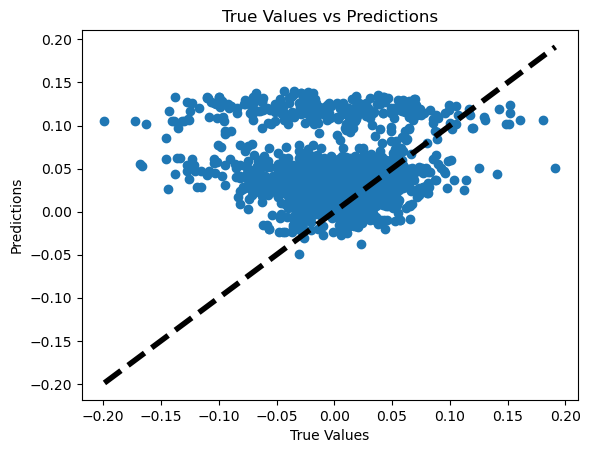

Feature Importance:


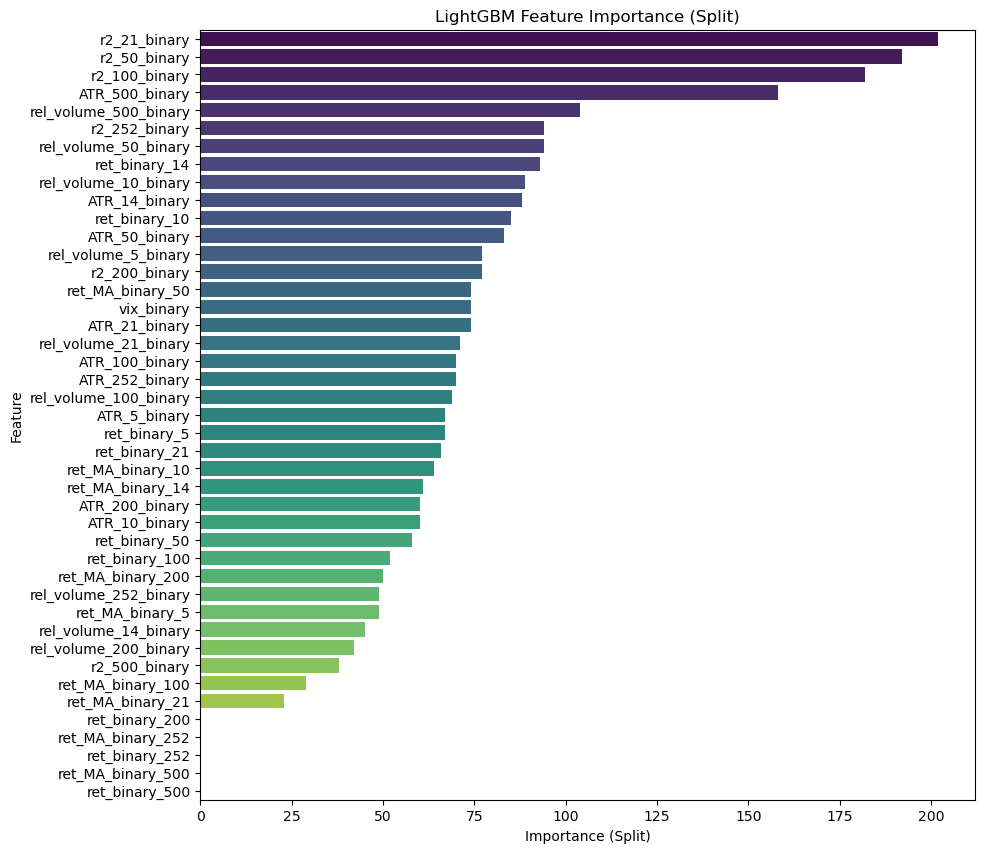

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000263 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 104
[LightGBM] [Info] Number of data points in the train set: 2527, number of used features: 43
[LightGBM] [Info] Start training from score 0.008427
RMSE: 0.004808579260087684


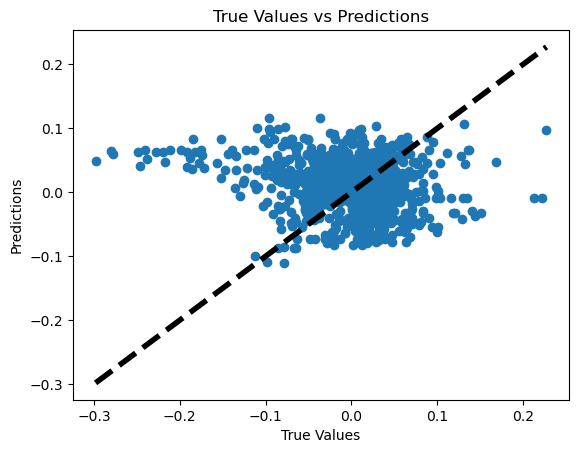

Feature Importance:


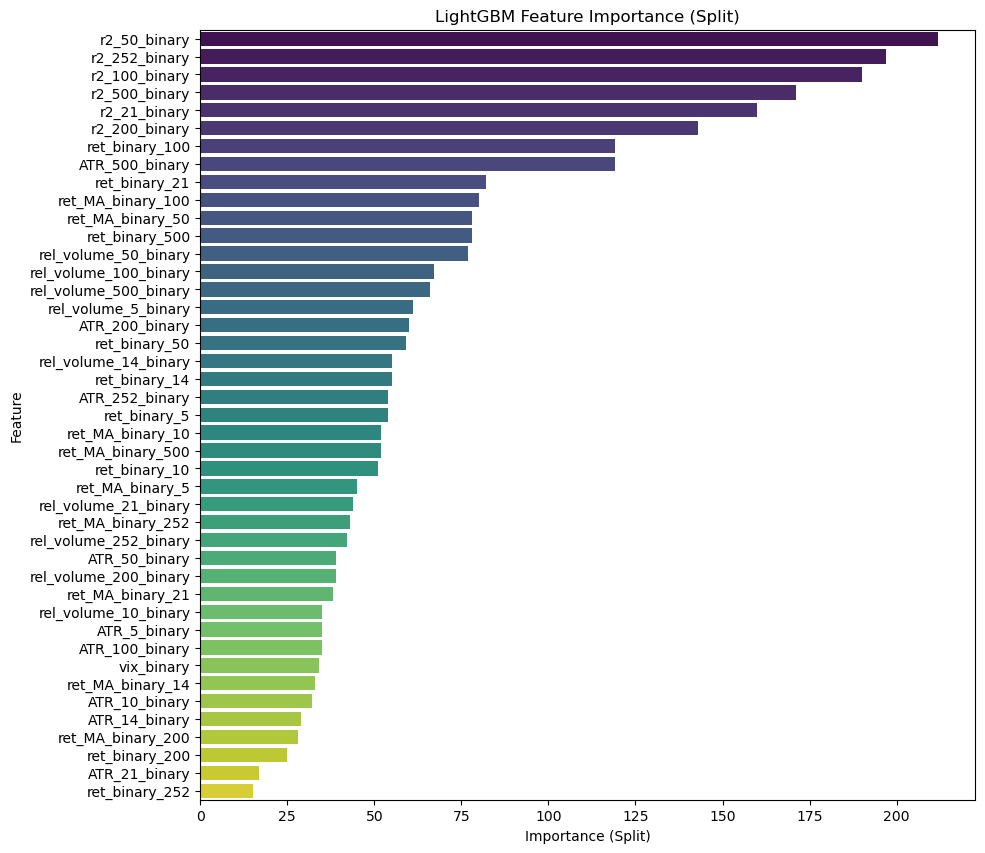

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000275 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 104
[LightGBM] [Info] Number of data points in the train set: 3788, number of used features: 43
[LightGBM] [Info] Start training from score 0.005672
RMSE: 0.0018208941664100747


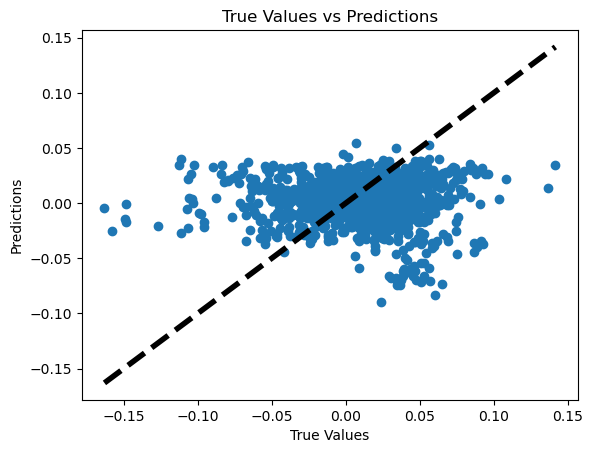

Feature Importance:


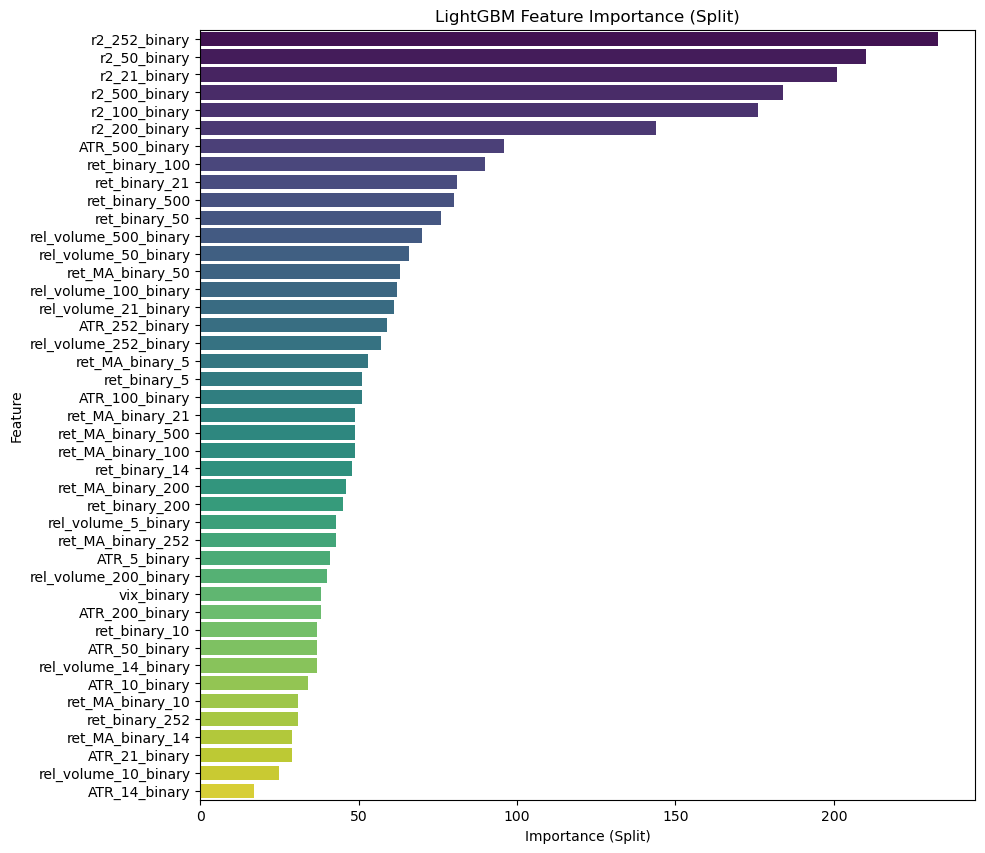

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000368 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 104
[LightGBM] [Info] Number of data points in the train set: 5049, number of used features: 43
[LightGBM] [Info] Start training from score 0.006964
RMSE: 0.0018657184843776007


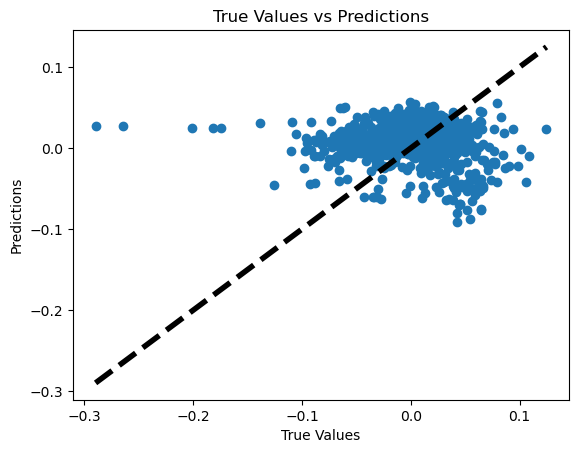

Feature Importance:


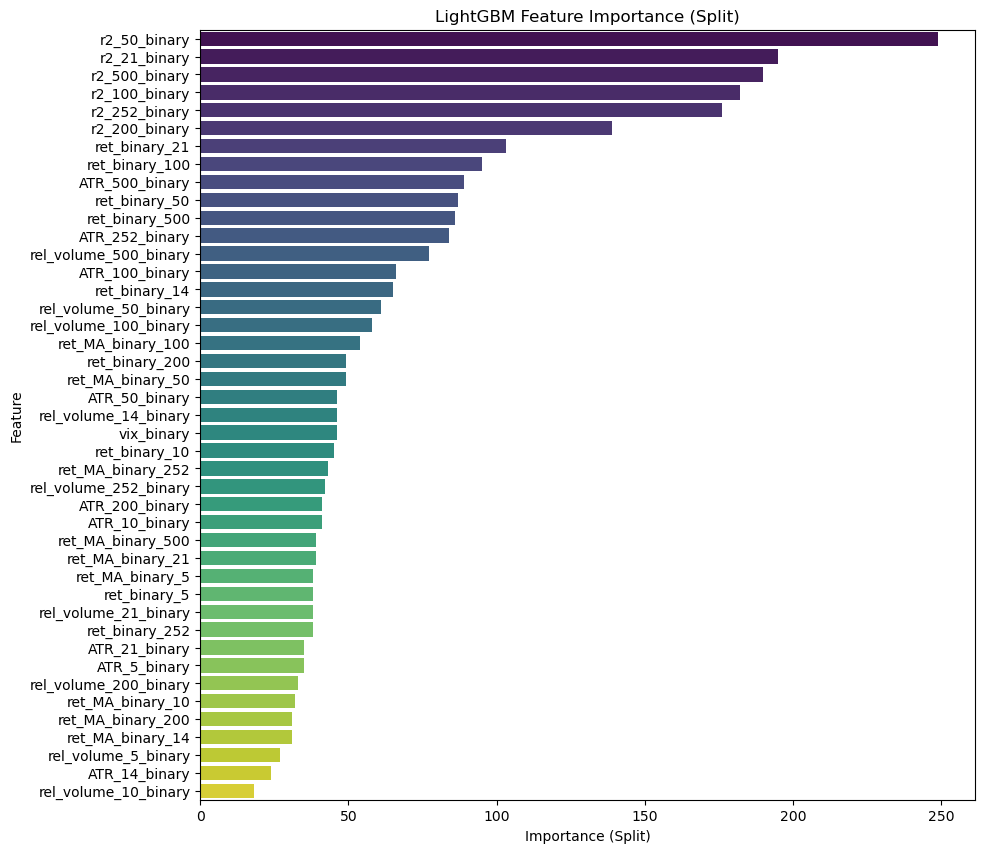

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000508 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 104
[LightGBM] [Info] Number of data points in the train set: 6310, number of used features: 43
[LightGBM] [Info] Start training from score 0.006834
RMSE: 0.0030190762494923017


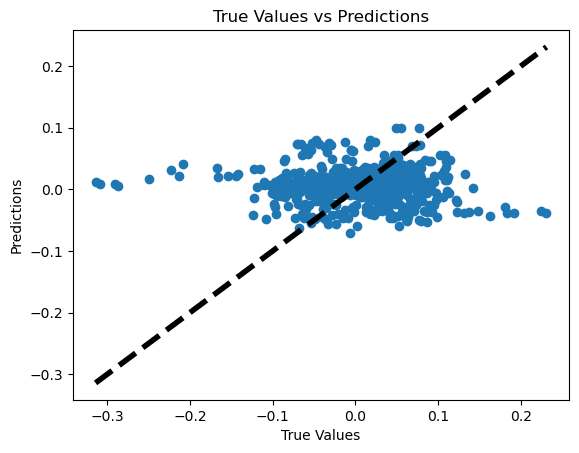

Feature Importance:


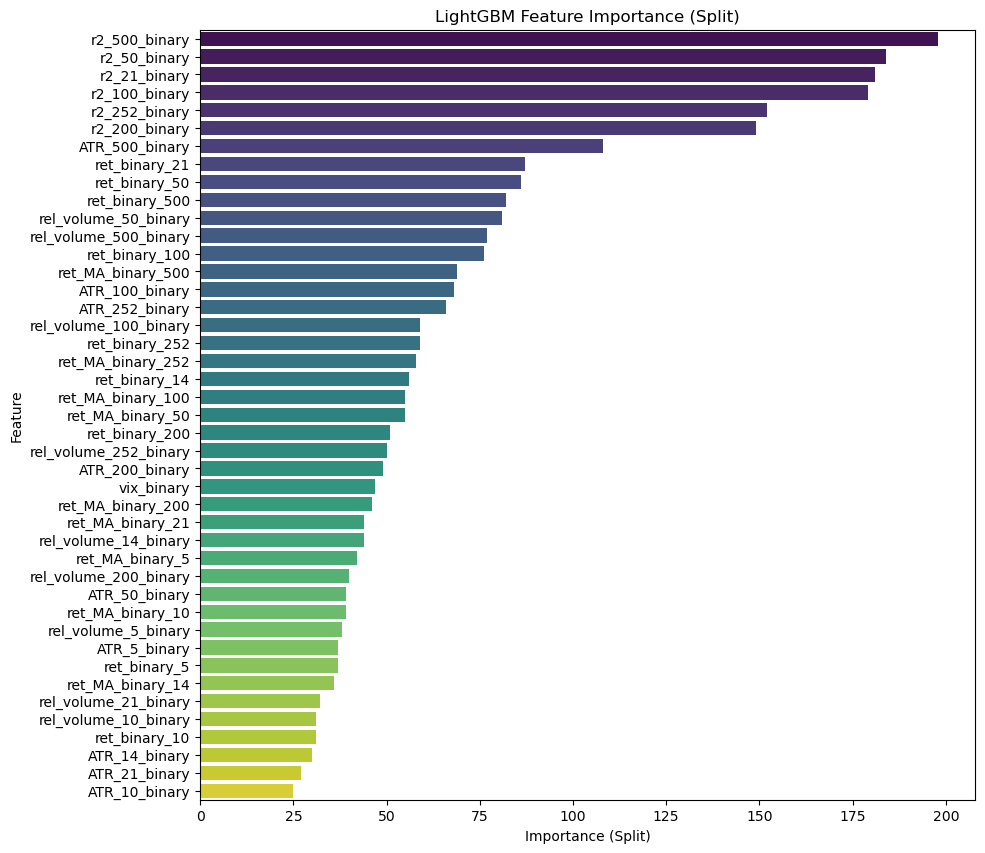

In [ ]:
import seaborn as sns

data = get_train_test_split(df_data, 5)

for i in tqdm(range(len(data))):
    X_train = data[i]['train'][train_cols]
    y_train = data[i]['train'][test_cols]
    X_test = data[i]['test'][train_cols]
    y_test = data[i]['test'][test_cols]


    model = lgb.LGBMRegressor()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    rmse = mean_squared_error(y_test, y_pred)
    print(f"RMSE: {rmse}")

    plt.scatter(y_test, y_pred)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=4)
    plt.xlabel('True Values')
    plt.ylabel('Predictions')
    plt.title('True Values vs Predictions')
    plt.show()

    # Get feature importance (split-based)
    feature_importance = model.feature_importances_

    # Create a DataFrame for feature importance
    importance_df = pd.DataFrame({
        'Feature': train_cols,
        'Importance': feature_importance
    })

    # Sort the DataFrame by importance
    importance_df = importance_df.sort_values(by='Importance', ascending=False)

    # Print the feature importance
    print("Feature Importance:")
    # print(importance_df)

    # Plot feature importance using seaborn
    plt.figure(figsize=(10, 10))
    sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis', hue='Feature')
    plt.xlabel('Importance (Split)')
    plt.ylabel('Feature')
    plt.title('LightGBM Feature Importance (Split)')
    plt.show()


In [ ]:
# Define the objective function for Optuna
def objective(trial):
    # Define hyperparameters to tune
    params = {
        'objective': 'regression',
        'metric': 'rmse',
        'boosting_type': trial.suggest_categorical('boosting_type', ['gbdt', 'dart', 'goss']),
        'num_leaves': trial.suggest_int('num_leaves', 10, 100),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 1.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.0, 1.0),
        'random_state': 42,
        'verbosity': -1,  # Suppress LightGBM logs
    }

    # Train the LightGBM model
    model = lgb.LGBMRegressor(**params)
    model.fit(X_train, y_train)

    # Make predictions on the test set
    y_pred = model.predict(X_test)

    # Calculate RMSE as the evaluation metric
    rmse = mean_squared_error(y_test, y_pred, squared=False)
    return rmse

# Create an Optuna study and optimize the objective function
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50)

# Print the best hyperparameters and RMSE
print("Best hyperparameters:", study.best_params)
print("Best RMSE:", study.best_value)

# Train the final model with the best hyperparameters
best_params = study.best_params
final_model = lgb.LGBMRegressor(**best_params, random_state=42)
final_model.fit(X_train, y_train)

# Evaluate the final model on the test set
y_pred_final = final_model.predict(X_test)
final_rmse = mean_squared_error(y_test, y_pred_final, squared=False)
print("Final RMSE:", final_rmse)

[I 2025-03-23 10:37:21,828] A new study created in memory with name: no-name-12cbef07-9d05-49e5-bfa9-e1541f07e699
[W 2025-03-23 10:37:22,000] Trial 0 failed with parameters: {'boosting_type': 'dart', 'num_leaves': 80, 'learning_rate': 0.033141456279393716, 'n_estimators': 160, 'max_depth': 9, 'min_child_samples': 69, 'subsample': 0.7742441442255072, 'colsample_bytree': 0.5034640706611682, 'reg_alpha': 0.5276909219855533, 'reg_lambda': 0.7479159278256041} because of the following error: TypeError("got an unexpected keyword argument 'squared'").
Traceback (most recent call last):
  File "c:\Users\alexr\miniconda3\envs\ai\Lib\site-packages\optuna\study\_optimize.py", line 200, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "C:\Users\alexr\AppData\Local\Temp\ipykernel_20636\4040507115.py", line 29, in objective
    rmse = mean_squared_error(y_test, y_pred, squared=False)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\

TypeError: got an unexpected keyword argument 'squared'

# END